In [1]:
import os
import glob

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
# INPUT_DIR = "/n/groups/kirschner/Will/BedRest/deseq2/cor/fgsea_res"
INPUT_DIR = "../outputs/cors2/fgsea_res"

In [3]:
adatas = {}
LE_dfs = {}

## KEGG

In [4]:
db = "KEGG"

In [5]:
# fgsea_fps_pos = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "pos", f"*.{db}.csv"))}
# fgsea_fps_neg = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "neg", f"*.{db}.csv"))}
fgsea_fps = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, f"*.{db}.csv"))}


pval_threshold = 1e-2


pvals = {}
NES = {}
LE = {}

for pheno_db, fgsea_fp in fgsea_fps.items():

    # fgsea_fp_neg = fgsea_fps_neg[pheno_db]
    # pheno, db = pheno_db.split(".")
    
    # fgsea_res_pos = pd.read_csv(fgsea_fp_pos).set_index("pathway")
    # fgsea_res_neg = pd.read_csv(fgsea_fp_neg).set_index("pathway")

    # fgsea_res_pos = fgsea_res_pos.loc[fgsea_res_pos.padj < pval_threshold,:]
    # fgsea_res_neg = fgsea_res_neg.loc[fgsea_res_neg.padj < pval_threshold,:]

    # fgsea_res = pd.concat([fgsea_res_pos, fgsea_res_neg], axis=0)

    pheno, db = pheno_db.split(".")
    
    fgsea_res = pd.read_csv(fgsea_fp).set_index("pathway")
    
    # fgsea_res = fgsea_res.loc[fgsea_res.padj < pval_threshold,:]
    # fgsea_res_neg = fgsea_res_neg.loc[fgsea_res_neg.padj < pval_threshold,:]

    # fgsea_res = pd.concat([fgsea_res_pos, fgsea_res_neg], axis=0)

    assert len(fgsea_res.index.unique()) == fgsea_res.shape[0]

    LE_len = fgsea_res.leadingEdge.str.split("|", expand=False).apply(len)
    LE_percentage = LE_len / fgsea_res["size"]
    
    LE[pheno_db] = LE_percentage
    NES[pheno_db] = fgsea_res.NES
    
    pvals[pheno_db] = fgsea_res.padj

In [6]:
LE_df = pd.concat(LE.values(), axis=1)
LE_df.columns = LE.keys()
LE_df.head()

,pre_FFA.KEGG,post_clamp_change_cho_ox.KEGG,post_cho_ox.KEGG,post_glucose_ven.KEGG,post_insulin_art.KEGG,pre_insulin_art.KEGG,pre_glucose_ven.KEGG,post_glucose_disposal.KEGG,post_FFA.KEGG,pre_clamp_change_fat_ox.KEGG,...,post_fat_ox.KEGG,pre_cho_ox.KEGG,pre_clamp_change_cho_ox.KEGG,post_glucose_art.KEGG,post_insulin_ven.KEGG,pre_insulin_ven.KEGG,pre_TAG.KEGG,pre_glucose_art.KEGG,post_TAG.KEGG,pre_glucose_disposal.KEGG
pathway,,,,,,,,,,,,,,,,,,,,,
2-Oxocarboxylic acid metabolism,0.629630,0.296296,0.333333,0.740741,0.777778,0.481481,0.666667,0.740741,0.407407,0.370370,...,0.333333,0.629630,0.444444,0.814815,0.740741,0.592593,0.259259,0.703704,0.703704,0.703704
ABC transporters,0.500000,0.147059,0.235294,0.352941,0.588235,0.441176,0.323529,0.235294,0.176471,0.382353,...,0.441176,0.411765,0.264706,0.411765,0.470588,0.176471,0.205882,0.294118,0.411765,0.294118
AGE-RAGE signaling pathway in diabetic complications,0.182796,0.236559,0.430108,0.279570,0.451613,0.301075,0.290323,0.322581,0.408602,0.301075,...,0.537634,0.215054,0.225806,0.311828,0.451613,0.494624,0.408602,0.301075,0.311828,0.387097
AMPK signaling pathway,0.242991,0.598131,0.383178,0.327103,0.373832,0.429907,0.401869,0.242991,0.364486,0.186916,...,0.289720,0.271028,0.467290,0.327103,0.327103,0.364486,0.280374,0.233645,0.439252,0.289720
ATP-dependent chromatin remodeling,0.391753,0.371134,0.515464,0.536082,0.237113,0.412371,0.402062,0.278351,0.432990,0.257732,...,0.350515,0.371134,0.237113,0.329897,0.505155,0.690722,0.453608,0.494845,0.278351,0.546392


In [7]:
pvals_df = pd.concat(pvals.values(), axis=1)
pvals_df.columns = pvals.keys()
pvals_df.head()

,pre_FFA.KEGG,post_clamp_change_cho_ox.KEGG,post_cho_ox.KEGG,post_glucose_ven.KEGG,post_insulin_art.KEGG,pre_insulin_art.KEGG,pre_glucose_ven.KEGG,post_glucose_disposal.KEGG,post_FFA.KEGG,pre_clamp_change_fat_ox.KEGG,...,post_fat_ox.KEGG,pre_cho_ox.KEGG,pre_clamp_change_cho_ox.KEGG,post_glucose_art.KEGG,post_insulin_ven.KEGG,pre_insulin_ven.KEGG,pre_TAG.KEGG,pre_glucose_art.KEGG,post_TAG.KEGG,pre_glucose_disposal.KEGG
pathway,,,,,,,,,,,,,,,,,,,,,
2-Oxocarboxylic acid metabolism,0.000027,1.000000,0.918458,0.037015,1.657618e-10,0.934932,0.000010,0.000466,0.013686,0.999196,...,0.262536,0.002219,0.010380,7.750785e-07,5.100711e-08,0.000112,0.285408,3.732479e-08,0.000154,1.463206e-08
ABC transporters,0.900591,1.000000,0.424287,0.326762,3.149641e-01,0.103597,0.823950,0.999157,0.915009,0.999196,...,0.411956,0.230420,0.798917,4.820167e-02,2.791756e-01,0.734434,0.963221,7.268579e-01,0.216462,5.883811e-01
AGE-RAGE signaling pathway in diabetic complications,0.999979,1.000000,0.516247,0.071629,7.261052e-03,0.074103,0.328196,0.504328,0.915009,0.999196,...,0.074322,0.545492,0.888996,1.656619e-02,6.640563e-01,0.900863,0.963221,2.468938e-01,0.078947,2.393532e-02
AMPK signaling pathway,0.227051,0.432535,0.077371,0.753444,1.098110e-03,0.684196,0.315306,0.748581,0.935981,0.810450,...,0.350978,0.432215,0.002561,1.911503e-02,9.453233e-01,0.880064,0.090298,1.299185e-01,0.000998,9.309451e-01
ATP-dependent chromatin remodeling,0.999979,0.227819,0.690630,0.012748,8.028906e-01,0.670418,0.035101,0.920725,0.033774,0.565490,...,0.747904,0.982698,0.283908,9.990389e-01,1.551056e-01,0.011881,0.011074,2.455302e-03,0.411139,3.133767e-03


In [8]:
NES_df = pd.concat(NES.values(), axis=1)
NES_df.columns = NES.keys()
NES_df.head()

,pre_FFA.KEGG,post_clamp_change_cho_ox.KEGG,post_cho_ox.KEGG,post_glucose_ven.KEGG,post_insulin_art.KEGG,pre_insulin_art.KEGG,pre_glucose_ven.KEGG,post_glucose_disposal.KEGG,post_FFA.KEGG,pre_clamp_change_fat_ox.KEGG,...,post_fat_ox.KEGG,pre_cho_ox.KEGG,pre_clamp_change_cho_ox.KEGG,post_glucose_art.KEGG,post_insulin_ven.KEGG,pre_insulin_ven.KEGG,pre_TAG.KEGG,pre_glucose_art.KEGG,post_TAG.KEGG,pre_glucose_disposal.KEGG
pathway,,,,,,,,,,,,,,,,,,,,,
2-Oxocarboxylic acid metabolism,-2.098140,0.831199,-0.758912,-1.668230,-3.002950,-0.731240,-2.778087,2.112668,-1.953861,-0.711391,...,-1.264083,2.198839,2.013558,-2.588166,-3.172975,-2.586513,-1.302488,-2.867756,-2.248578,3.251762
ABC transporters,-0.983458,0.722110,-1.186581,1.229900,1.175198,1.526570,0.881044,-0.491027,0.822446,0.872312,...,1.148221,1.404424,0.925846,1.544608,1.236190,-0.945893,-0.862355,0.890182,1.353418,-1.002668
AGE-RAGE signaling pathway in diabetic complications,-0.912154,0.785400,-1.083708,1.387584,1.633668,1.437819,1.184207,1.146688,0.867666,0.805123,...,1.438534,1.133577,0.875596,1.554917,0.983447,0.856070,0.889306,1.214891,1.419518,-1.431951
AMPK signaling pathway,-1.297617,1.202187,-1.444682,-0.992909,-1.756947,-1.027750,1.184809,1.008955,0.831721,-1.092436,...,1.157057,1.172253,1.869581,-1.488349,0.726817,0.885761,-1.256252,-1.254510,-1.811439,-0.755833
ATP-dependent chromatin remodeling,-0.588888,1.279907,-0.992595,-1.604142,-0.874967,-1.046240,1.450188,0.867591,1.466724,1.322655,...,0.923661,-0.869768,-1.239634,-0.607337,1.262550,1.523373,1.525556,1.732141,-1.134984,-1.566266


In [9]:
pval_threshold = 5e-2

NES_df[pvals_df >= pval_threshold] = np.nan
NES_df = NES_df.loc[~NES_df.isna().all(axis=1),:]

In [10]:
adata = ad.AnnData(NES_df.values)

adata.var_names = NES_df.columns
adata.obs_names = NES_df.index

adata.obs["pathway"] = pd.Categorical(adata.obs_names)
adata.obs.index.rename("index", inplace=True)
# adata.obs

In [11]:
markers_ = {colname: colname.split("_", maxsplit=1)[1].split(".")[0] for colname in adata.var_names}

markers__ = {}

for key, value in markers_.items():
    if value in markers__:
        markers__[value].append(key)
    else:
        markers__[value] = [key,]

for key, value in markers__.items():
    markers__[key] = list(reversed(sorted(markers__[key])))

In [12]:
markers__

{'FFA': ['pre_FFA.KEGG', 'post_FFA.KEGG'],
 'clamp_change_cho_ox': ['pre_clamp_change_cho_ox.KEGG',
  'post_clamp_change_cho_ox.KEGG'],
 'cho_ox': ['pre_cho_ox.KEGG', 'post_cho_ox.KEGG'],
 'glucose_ven': ['pre_glucose_ven.KEGG', 'post_glucose_ven.KEGG'],
 'insulin_art': ['pre_insulin_art.KEGG', 'post_insulin_art.KEGG'],
 'glucose_disposal': ['pre_glucose_disposal.KEGG',
  'post_glucose_disposal.KEGG'],
 'clamp_change_fat_ox': ['pre_clamp_change_fat_ox.KEGG',
  'post_clamp_change_fat_ox.KEGG'],
 'fat_ox': ['pre_fat_ox.KEGG', 'post_fat_ox.KEGG'],
 'glucose_art': ['pre_glucose_art.KEGG', 'post_glucose_art.KEGG'],
 'insulin_ven': ['pre_insulin_ven.KEGG', 'post_insulin_ven.KEGG'],
 'TAG': ['pre_TAG.KEGG', 'post_TAG.KEGG']}

In [13]:
markers = {}
ordered = ["glucose_ven", "glucose_art", "insulin_ven", "insulin_art", "glucose_disposal", "FFA", "TAG", "cho_ox", "clamp_change_cho_ox", "fat_ox", "clamp_change_fat_ox"]
for key in ordered:
    markers[key] = markers__[key]

In [14]:
markers

{'glucose_ven': ['pre_glucose_ven.KEGG', 'post_glucose_ven.KEGG'],
 'glucose_art': ['pre_glucose_art.KEGG', 'post_glucose_art.KEGG'],
 'insulin_ven': ['pre_insulin_ven.KEGG', 'post_insulin_ven.KEGG'],
 'insulin_art': ['pre_insulin_art.KEGG', 'post_insulin_art.KEGG'],
 'glucose_disposal': ['pre_glucose_disposal.KEGG',
  'post_glucose_disposal.KEGG'],
 'FFA': ['pre_FFA.KEGG', 'post_FFA.KEGG'],
 'TAG': ['pre_TAG.KEGG', 'post_TAG.KEGG'],
 'cho_ox': ['pre_cho_ox.KEGG', 'post_cho_ox.KEGG'],
 'clamp_change_cho_ox': ['pre_clamp_change_cho_ox.KEGG',
  'post_clamp_change_cho_ox.KEGG'],
 'fat_ox': ['pre_fat_ox.KEGG', 'post_fat_ox.KEGG'],
 'clamp_change_fat_ox': ['pre_clamp_change_fat_ox.KEGG',
  'post_clamp_change_fat_ox.KEGG']}

In [15]:
cols = []
for key, value in markers.items():
    cols += value
cols

['pre_glucose_ven.KEGG',
 'post_glucose_ven.KEGG',
 'pre_glucose_art.KEGG',
 'post_glucose_art.KEGG',
 'pre_insulin_ven.KEGG',
 'post_insulin_ven.KEGG',
 'pre_insulin_art.KEGG',
 'post_insulin_art.KEGG',
 'pre_glucose_disposal.KEGG',
 'post_glucose_disposal.KEGG',
 'pre_FFA.KEGG',
 'post_FFA.KEGG',
 'pre_TAG.KEGG',
 'post_TAG.KEGG',
 'pre_cho_ox.KEGG',
 'post_cho_ox.KEGG',
 'pre_clamp_change_cho_ox.KEGG',
 'post_clamp_change_cho_ox.KEGG',
 'pre_fat_ox.KEGG',
 'post_fat_ox.KEGG',
 'pre_clamp_change_fat_ox.KEGG',
 'post_clamp_change_fat_ox.KEGG']

In [16]:
assert (LE_df.columns == adata.var_names).all()
LE_df = LE_df.loc[adata.obs_names,:]
LE_df[np.isnan(adata.X)] = 0
LE_df = LE_df[cols]

In [91]:
adata.obs["abs_max"] = np.nanmax(abs(adata.X), axis=1, )
adata = adata[adata.obs.sort_values("abs_max", ascending=False).index,:].copy()
adata.obs.pathway = pd.Categorical(adata.obs.pathway, ordered=True, categories=adata.obs.pathway)

In [17]:
LE_df = LE_df.loc[adata.obs_names,:].copy()

In [22]:
bs = 25
save_fig = True

assert (adata.obs_names == LE_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=LE_df.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True
    ) #, dendrogram=True)
    
    p.grid=True
    p.group_cmaps = None
    p.make_figure()

    
    if save_fig:
        plt.savefig(f'figures_thresholded/KEGG_{i}.png', bbox_inches='tight')
        plt.close()

In [15]:
kegg_hl = """2-Oxocarboxylic acid metabolism
Antigen processing and presentation
B cell receptor signaling pathway
Biosynthesis of unsaturated fatty acids
Carbon metabolism
Cell adhesion molecule (CAM) interaction
Citrate cycle (TCA cycle)
Cytokine-cytokine receptor interaction
Fatty acid degradation
Fatty acid elongation
Fatty acid metabolism
Fc epsilon RI signaling pathway
Fc gamma R-mediated phagocytosis
Glycolysis / Gluconeogenesis
Glyoxylate and dicarboxylate metabolism
Leukocyte transendothelial migration
Lipoic acid metabolism
NF-kappa B signaling pathway
Natural killer cell mediated cytotoxicity
Non-alcoholic fatty liver disease
Oxidative phosphorylation
Pentose phosphate pathway
Ribosome
TNF signaling pathway
Thermogenesis
Valine, leucine and isoleucine degradation
Viral protein interaction with cytokine and cytokine receptor""".split("\n")

In [16]:
adatas["KEGG"] = adata[adata.obs_names.isin(kegg_hl),:].copy()

In [17]:
LE_dfs["KEGG"] = LE_df.loc[LE_df.index.isin(kegg_hl),:].copy()

In [23]:
metabolic_pathways = [
    "Insulin signaling pathway",  
    # "Insulin resistance",  
    "Glucagon signaling pathway",
    "Glycolysis / Gluconeogenesis",  
    "Pyruvate metabolism",
    "Pentose phosphate pathway",  
    # "Fat digestion and absorption",
    # "Cholesterol metabolism",  
    "Glycerolipid metabolism",  
    "Fatty acid biosynthesis",  
    "Fatty acid elongation",  
    "Fatty acid degradation",
    "Fatty acid metabolism",  
    "Citrate cycle (TCA cycle)",  
    "Oxidative phosphorylation",
    "Glyoxylate and dicarboxylate metabolism",  
    "Peroxisome",
    "PPAR signaling pathway",  
    "mTOR signaling pathway",
    "AMPK signaling pathway",
    "2-Oxocarboxylic acid metabolism",
    "FoxO signaling pathway",  
    "cGMP-PKG signaling pathway",  
    "Glutathione metabolism",  
    "Ribosome",
    "AGE-RAGE signaling pathway in diabetic complications",  
    # "Type II diabetes mellitus",  
    # "Ferroptosis",
    "Apoptosis",
    "Mitophagy - animal",  
    "Autophagy - animal", 
    "Cellular senescence", 
    # "HIF-1 signaling pathway",
    "Chemical carcinogenesis - reactive oxygen species"
]

In [30]:
# markers.pop("cho_ox")
markers.pop("fat_ox")

['pre_fat_ox.KEGG', 'post_fat_ox.KEGG']

In [31]:
adata_sub = adata[metabolic_pathways,:]

In [36]:
LE_df_sub = LE_df.loc[metabolic_pathways,['pre_glucose_ven.KEGG', 'post_glucose_ven.KEGG', 'pre_glucose_art.KEGG',
       'post_glucose_art.KEGG', 'pre_insulin_ven.KEGG',
       'post_insulin_ven.KEGG', 'pre_insulin_art.KEGG',
       'post_insulin_art.KEGG', 'pre_glucose_disposal.KEGG',
       'post_glucose_disposal.KEGG', 'pre_FFA.KEGG', 'post_FFA.KEGG',
       'pre_TAG.KEGG', 'post_TAG.KEGG',
       'pre_clamp_change_cho_ox.KEGG', 'post_clamp_change_cho_ox.KEGG',
       'pre_clamp_change_fat_ox.KEGG',
       'post_clamp_change_fat_ox.KEGG']]

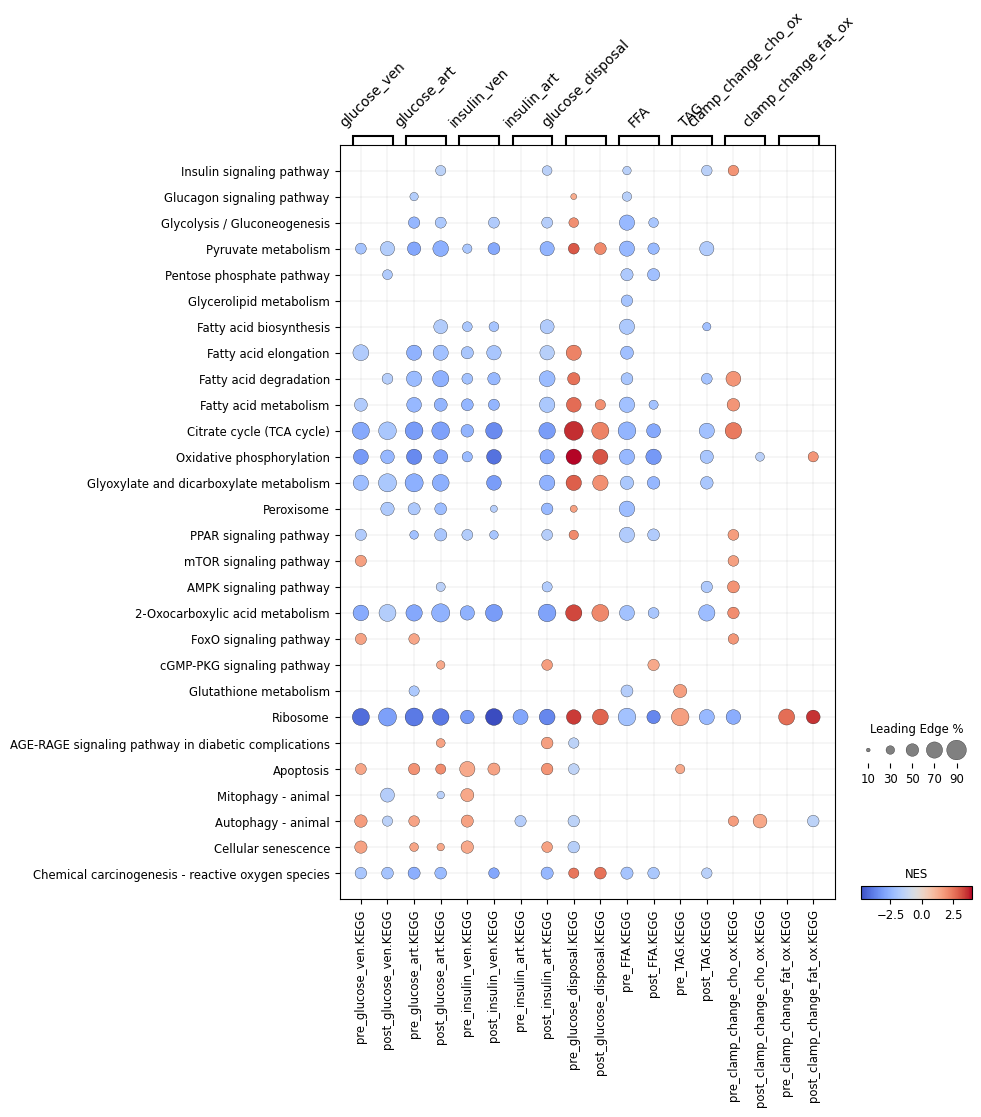

In [37]:
# bs = 25
save_fig = False

assert (adata_sub.obs_names == LE_df_sub.index).all()

p = dotplot(
    adata_sub,
    var_names=markers,
    groupby="pathway",
    expression_cutoff=-100,
    vmin=np.nanmin(adata_sub.X),
    vmax=np.nanmax(adata_sub.X),
    cmap="coolwarm",
    dot_size_df=LE_df_sub,
    # swap_axes=True,
    return_fig=True,
    categories_order=adata_sub.obs_names,
    var_group_rotation=45,
) #, dendrogram=True)

p.grid=True
p.group_cmaps = None
p.make_figure()


if save_fig:
    plt.savefig(f'figures_ranked/KEGG_{i}.png', bbox_inches='tight')
    plt.close()

In [38]:
immune_pathways = """NF-kappa B signaling pathway
TNF signaling pathway
JAK-STAT signaling pathway
Phospholipase D signaling pathway
p53 signaling pathway
Antigen processing and presentation
Fc gamma R-mediated phagocytosis
Toll-like receptor signaling pathway
Leukocyte transendothelial migration
Chemokine signaling pathway
B cell receptor signaling pathway
Th1 and Th2 cell differentiation
Th17 cell differentiation
IL-17 signaling pathway
PD-L1 expression and PD-1 checkpoint pathway in cancer
T cell receptor signaling pathway
Natural killer cell mediated cytotoxicity
Neutrophil extracellular trap formation""".split("\n")

In [39]:
adata_sub = adata[immune_pathways,:]

In [40]:
LE_df_sub = LE_df.loc[immune_pathways,['pre_glucose_ven.KEGG', 'post_glucose_ven.KEGG', 'pre_glucose_art.KEGG',
       'post_glucose_art.KEGG', 'pre_insulin_ven.KEGG',
       'post_insulin_ven.KEGG', 'pre_insulin_art.KEGG',
       'post_insulin_art.KEGG', 'pre_glucose_disposal.KEGG',
       'post_glucose_disposal.KEGG', 'pre_FFA.KEGG', 'post_FFA.KEGG',
       'pre_TAG.KEGG', 'post_TAG.KEGG',
       'pre_clamp_change_cho_ox.KEGG', 'post_clamp_change_cho_ox.KEGG',
       'pre_clamp_change_fat_ox.KEGG',
       'post_clamp_change_fat_ox.KEGG']]

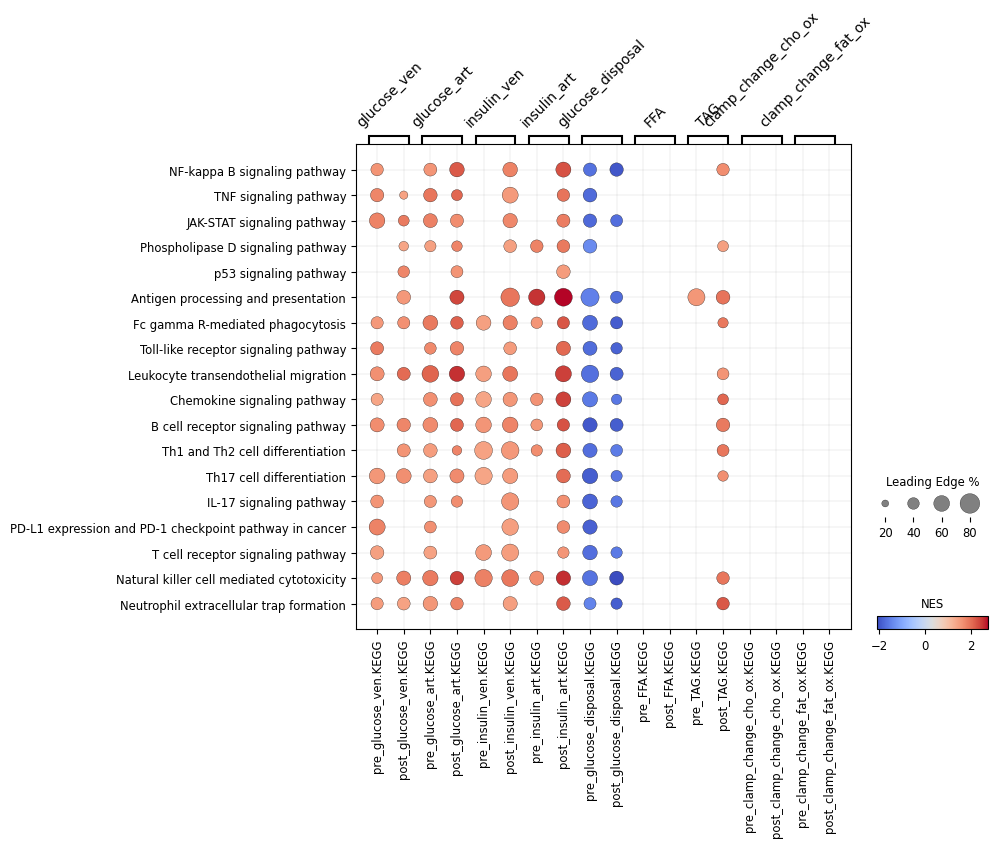

In [41]:
# bs = 25
save_fig = False

assert (adata_sub.obs_names == LE_df_sub.index).all()

p = dotplot(
    adata_sub,
    var_names=markers,
    groupby="pathway",
    expression_cutoff=-100,
    vmin=np.nanmin(adata_sub.X),
    vmax=np.nanmax(adata_sub.X),
    cmap="coolwarm",
    dot_size_df=LE_df_sub,
    # swap_axes=True,
    return_fig=True,
    categories_order=adata_sub.obs_names,
    var_group_rotation=45,
) #, dendrogram=True)

p.grid=True
p.group_cmaps = None
p.make_figure()


if save_fig:
    plt.savefig(f'figures_ranked/KEGG_{i}.png', bbox_inches='tight')
    plt.close()

## GO BP

In [70]:
db = "GOBP"

In [71]:
fgsea_fps_pos = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "pos", f"*.{db}.csv"))}
fgsea_fps_neg = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "neg", f"*.{db}.csv"))}


pval_threshold = 1e-2


# pvals = {}
NES = {}
LE = {}

for pheno_db, fgsea_fp_pos in fgsea_fps_pos.items():

    fgsea_fp_neg = fgsea_fps_neg[pheno_db]
    pheno, db = pheno_db.split(".")
    
    fgsea_res_pos = pd.read_csv(fgsea_fp_pos).set_index("pathway")
    fgsea_res_neg = pd.read_csv(fgsea_fp_neg).set_index("pathway")

    fgsea_res_pos = fgsea_res_pos.loc[fgsea_res_pos.padj < pval_threshold,:]
    fgsea_res_neg = fgsea_res_neg.loc[fgsea_res_neg.padj < pval_threshold,:]

    fgsea_res = pd.concat([fgsea_res_pos, fgsea_res_neg], axis=0)

    assert len(fgsea_res.index.unique()) == fgsea_res.shape[0]

    LE_len = fgsea_res.leadingEdge.str.split("|", expand=False).apply(len)
    LE_percentage = LE_len / fgsea_res["size"]
    
    LE[pheno_db] = LE_percentage
    NES[pheno_db] = fgsea_res.ES
    
    # pvals[pheno_db] = fgsea_res.padj

In [72]:
LE_df = pd.concat(LE.values(), axis=1)
LE_df.columns = LE.keys()
LE_df.head()

,pre_fat_ox.GOBP,post_FFA.GOBP,pre_glucose_ven.GOBP,post_glucose_disposal.GOBP,pre_insulin_art.GOBP,post_insulin_art.GOBP,post_glucose_ven.GOBP,post_cho_ox.GOBP,pre_FFA.GOBP,pre_glucose_disposal.GOBP,post_TAG.GOBP,pre_glucose_art.GOBP,pre_TAG.GOBP,pre_insulin_ven.GOBP,post_insulin_ven.GOBP,post_glucose_art.GOBP,pre_cho_ox.GOBP,post_fat_ox.GOBP
pathway,,,,,,,,,,,,,,,,,,
GOBP_CYTOPLASMIC_TRANSLATION,0.521212,0.569697,0.533333,0.612121,0.630303,0.636364,0.715152,0.339394,NaN,0.545455,0.509091,0.581818,0.709091,0.606061,0.715152,0.648485,0.757576,0.557576
GOBP_RNA_SPLICING,NaN,0.425234,NaN,NaN,0.394860,NaN,0.350467,NaN,NaN,NaN,NaN,NaN,0.446262,0.348131,NaN,NaN,0.425234,NaN
GOBP_ACETYL_COA_BIOSYNTHETIC_PROCESS,NaN,0.450000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GOBP_ACETYL_COA_METABOLIC_PROCESS,NaN,0.500000,NaN,0.406250,NaN,0.531250,NaN,NaN,0.500000,NaN,NaN,0.468750,NaN,NaN,0.687500,0.625000,NaN,NaN
GOBP_ACYL_COA_METABOLIC_PROCESS,NaN,0.367089,NaN,0.405063,NaN,0.468354,NaN,NaN,0.468354,NaN,NaN,0.468354,NaN,NaN,0.708861,0.556962,NaN,NaN


pvals_df = pd.concat(pvals.values(), axis=1)
pvals_df.columns = pvals.keys()
pvals_df.head()

In [73]:
NES_df = pd.concat(NES.values(), axis=1)
NES_df.columns = NES.keys()
NES_df.head()

,pre_fat_ox.GOBP,post_FFA.GOBP,pre_glucose_ven.GOBP,post_glucose_disposal.GOBP,pre_insulin_art.GOBP,post_insulin_art.GOBP,post_glucose_ven.GOBP,post_cho_ox.GOBP,pre_FFA.GOBP,pre_glucose_disposal.GOBP,post_TAG.GOBP,pre_glucose_art.GOBP,pre_TAG.GOBP,pre_insulin_ven.GOBP,post_insulin_ven.GOBP,post_glucose_art.GOBP,pre_cho_ox.GOBP,post_fat_ox.GOBP
pathway,,,,,,,,,,,,,,,,,,
GOBP_CYTOPLASMIC_TRANSLATION,0.443629,-0.474864,-0.436625,-0.680130,-0.631389,-0.577797,-0.655969,0.255888,NaN,-0.507937,-0.384972,-0.443793,0.463919,0.671673,0.598528,-0.616217,-0.531428,-0.482774
GOBP_RNA_SPLICING,NaN,0.378081,NaN,NaN,-0.381938,NaN,-0.354794,NaN,NaN,NaN,NaN,NaN,0.389371,0.293366,NaN,NaN,-0.366356,NaN
GOBP_ACETYL_COA_BIOSYNTHETIC_PROCESS,NaN,-0.576074,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GOBP_ACETYL_COA_METABOLIC_PROCESS,NaN,-0.575538,NaN,-0.511764,NaN,-0.572659,NaN,NaN,-0.667634,NaN,NaN,-0.476788,NaN,NaN,0.565545,-0.595696,NaN,NaN
GOBP_ACYL_COA_METABOLIC_PROCESS,NaN,-0.379549,NaN,-0.383319,NaN,-0.486297,NaN,NaN,-0.602167,NaN,NaN,-0.475027,NaN,NaN,0.540056,-0.533345,NaN,NaN


pval_threshold = 5e-2

NES_df[pvals_df >= pval_threshold] = np.nan
NES_df = NES_df.loc[~NES_df.isna().all(axis=1),:]

In [74]:
adata = ad.AnnData(NES_df.values)

adata.var_names = NES_df.columns
adata.obs_names = NES_df.index

adata.obs["pathway"] = pd.Categorical(adata.obs_names)
adata.obs.index.rename("index", inplace=True)
# adata.obs

In [75]:
markers_ = {colname: colname.split("_", maxsplit=1)[1].split(".")[0] for colname in adata.var_names}

markers = {}
for key, value in markers_.items():
    if value in markers:
        markers[value].append(key)
    else:
        markers[value] = [key,]

for key, value in markers.items():
    markers[key] = list(reversed(sorted(markers[key])))

In [76]:
cols = []
for key, value in markers.items():
    cols += value
cols

['pre_fat_ox.GOBP',
 'post_fat_ox.GOBP',
 'pre_FFA.GOBP',
 'post_FFA.GOBP',
 'pre_glucose_ven.GOBP',
 'post_glucose_ven.GOBP',
 'pre_glucose_disposal.GOBP',
 'post_glucose_disposal.GOBP',
 'pre_insulin_art.GOBP',
 'post_insulin_art.GOBP',
 'pre_cho_ox.GOBP',
 'post_cho_ox.GOBP',
 'pre_TAG.GOBP',
 'post_TAG.GOBP',
 'pre_glucose_art.GOBP',
 'post_glucose_art.GOBP',
 'pre_insulin_ven.GOBP',
 'post_insulin_ven.GOBP']

In [77]:
assert (LE_df.columns == adata.var_names).all()
LE_df = LE_df.loc[adata.obs_names,:]
LE_df[np.isnan(adata.X)] = 0
LE_df = LE_df[cols]

In [78]:
adata.obs["abs_max"] = np.nanmax(abs(adata.X), axis=1, )
adata = adata[adata.obs.sort_values("abs_max", ascending=False).index,:].copy()
adata.obs.pathway = pd.Categorical(adata.obs.pathway, ordered=True, categories=adata.obs.pathway)

In [79]:
LE_df = LE_df.loc[adata.obs_names,:].copy()

In [80]:
bs = 50
save_fig = True

assert (adata.obs_names == LE_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=LE_df.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True
    ) #, dendrogram=True)
    
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    if save_fig:
        plt.savefig(f'figures/{db}_{i}.png', bbox_inches='tight')
        plt.close()

In [173]:
gobp_hl = """GOBP_ACTIVATION_OF_IMMUNE_RESPONSE
GOBP_ACTIVATION_OF_INNATE_IMMUNE_RESPONSE
GOBP_ADAPTIVE_IMMUNE_RESPONSE
GOBP_AEROBIC_RESPIRATION
GOBP_ALPHA_AMINO_ACID_METABOLIC_PROCESS
GOBP_ALPHA_BETA_T_CELL_ACTIVATION
GOBP_ALPHA_BETA_T_CELL_DIFFERENTIATION
GOBP_ALPHA_BETA_T_CELL_PROLIFERATION
GOBP_AMINO_ACID_CATABOLIC_PROCESS
GOBP_AMINO_ACID_METABOLIC_PROCESS
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_ENDOGENOUS_ANTIGEN
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_ANTIGEN
GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN
GOBP_ANTIGEN_RECEPTOR_MEDIATED_SIGNALING_PATHWAY
GOBP_ATP_BIOSYNTHETIC_PROCESS
GOBP_ATP_METABOLIC_PROCESS
GOBP_ATP_SYNTHESIS_COUPLED_ELECTRON_TRANSPORT
GOBP_BRANCHED_CHAIN_AMINO_ACID_METABOLIC_PROCESS
GOBP_B_CELL_ACTIVATION
GOBP_B_CELL_DIFFERENTIATION
GOBP_B_CELL_PROLIFERATION
GOBP_B_CELL_RECEPTOR_SIGNALING_PATHWAY
GOBP_CD4_POSITIVE_ALPHA_BETA_T_CELL_DIFFERENTIATION
GOBP_CELLULAR_DEFENSE_RESPONSE
GOBP_CELLULAR_EXTRAVASATION
GOBP_CELLULAR_RESPIRATION
GOBP_CYTOKINE_MEDIATED_SIGNALING_PATHWAY
GOBP_CYTOPLASMIC_TRANSLATION
GOBP_CYTOPLASMIC_TRANSLATIONAL_INITIATION
GOBP_DENDRITIC_CELL_CHEMOTAXIS
GOBP_DENDRITIC_CELL_DIFFERENTIATION
GOBP_DENDRITIC_CELL_MIGRATION
GOBP_ELECTRON_TRANSPORT_CHAIN
GOBP_FATTY_ACID_BETA_OXIDATION
GOBP_FATTY_ACID_CATABOLIC_PROCESS
GOBP_FATTY_ACID_DERIVATIVE_BIOSYNTHETIC_PROCESS
GOBP_FATTY_ACID_DERIVATIVE_METABOLIC_PROCESS
GOBP_FATTY_ACID_METABOLIC_PROCESS
GOBP_FC_GAMMA_RECEPTOR_SIGNALING_PATHWAY
GOBP_FC_RECEPTOR_SIGNALING_PATHWAY
GOBP_GRANULOCYTE_ACTIVATION
GOBP_GRANULOCYTE_CHEMOTAXIS
GOBP_GRANULOCYTE_MIGRATION
GOBP_IMMUNE_EFFECTOR_PROCESS
GOBP_IMMUNE_RESPONSE_REGULATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY
GOBP_IMMUNE_RESPONSE_REGULATING_SIGNALING_PATHWAY
GOBP_INNATE_IMMUNE_RESPONSE_ACTIVATING_CELL_SURFACE_RECEPTOR_SIGNALING_PATHWAY
GOBP_INNER_MITOCHONDRIAL_MEMBRANE_ORGANIZATION
GOBP_INTERLEUKIN_10_PRODUCTION
GOBP_INTERLEUKIN_1_BETA_PRODUCTION
GOBP_INTERLEUKIN_1_PRODUCTION
GOBP_INTERLEUKIN_6_PRODUCTION
GOBP_LEUKOCYTE_CELL_CELL_ADHESION
GOBP_LEUKOCYTE_CHEMOTAXIS
GOBP_LEUKOCYTE_DEGRANULATION
GOBP_LEUKOCYTE_DIFFERENTIATION
GOBP_LEUKOCYTE_HOMEOSTASIS
GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY
GOBP_LEUKOCYTE_MEDIATED_IMMUNITY
GOBP_LEUKOCYTE_MIGRATION
GOBP_LEUKOCYTE_PROLIFERATION
GOBP_LIPID_MODIFICATION
GOBP_LIPID_OXIDATION
GOBP_LIPOPOLYSACCHARIDE_MEDIATED_SIGNALING_PATHWAY
GOBP_LONG_CHAIN_FATTY_ACID_BIOSYNTHETIC_PROCESS
GOBP_LONG_CHAIN_FATTY_ACID_METABOLIC_PROCESS
GOBP_LYMPHOCYTE_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_LYMPHOCYTE_CHEMOTAXIS
GOBP_LYMPHOCYTE_DIFFERENTIATION
GOBP_LYMPHOCYTE_MEDIATED_IMMUNITY
GOBP_LYMPHOCYTE_MIGRATION
GOBP_MACROPHAGE_ACTIVATION
GOBP_MAST_CELL_ACTIVATION
GOBP_MAST_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_CYTOCHROME_C_TO_OXYGEN
GOBP_MITOCHONDRIAL_ELECTRON_TRANSPORT_NADH_TO_UBIQUINONE
GOBP_MITOCHONDRIAL_GENE_EXPRESSION
GOBP_MITOCHONDRIAL_MEMBRANE_ORGANIZATION
GOBP_MITOCHONDRIAL_RESPIRATORY_CHAIN_COMPLEX_ASSEMBLY
GOBP_MITOCHONDRIAL_TRANSLATION
GOBP_MITOCHONDRIAL_TRANSMEMBRANE_TRANSPORT
GOBP_MITOCHONDRIAL_TRANSPORT
GOBP_MITOCHONDRION_ORGANIZATION
GOBP_MONOCARBOXYLIC_ACID_CATABOLIC_PROCESS
GOBP_MYELOID_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_MYELOID_CELL_DIFFERENTIATION
GOBP_MYELOID_LEUKOCYTE_ACTIVATION
GOBP_MYELOID_LEUKOCYTE_DIFFERENTIATION
GOBP_MYELOID_LEUKOCYTE_MEDIATED_IMMUNITY
GOBP_MYELOID_LEUKOCYTE_MIGRATION
GOBP_NADH_DEHYDROGENASE_COMPLEX_ASSEMBLY
GOBP_NEUTROPHIL_CHEMOTAXIS
GOBP_NEUTROPHIL_MEDIATED_IMMUNITY
GOBP_NEUTROPHIL_MIGRATION
GOBP_POSITIVE_REGULATION_OF_TYPE_II_INTERFERON_PRODUCTION
GOBP_PROTEIN_LOCALIZATION_TO_MITOCHONDRION
GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS
GOBP_PROTON_TRANSMEMBRANE_TRANSPORT
GOBP_RIBONUCLEOPROTEIN_COMPLEX_BIOGENESIS
GOBP_RIBOSE_PHOSPHATE_BIOSYNTHETIC_PROCESS
GOBP_RIBOSE_PHOSPHATE_METABOLIC_PROCESS
GOBP_RIBOSOMAL_SMALL_SUBUNIT_BIOGENESIS
GOBP_RIBOSOME_BIOGENESIS
GOBP_RRNA_METABOLIC_PROCESS
GOBP_RRNA_PROCESSING
GOBP_CELLULAR_RESPONSE_TO_TYPE_II_INTERFERON
GOBP_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_CELL_ADHESION_MEDIATED_BY_INTEGRIN
GOBP_CELL_CHEMOTAXIS
GOBP_CELL_KILLING
GOBP_CHEMOKINE_PRODUCTION
GOBP_ORGANIC_ACID_CATABOLIC_PROCESS
GOBP_OXIDATIVE_PHOSPHORYLATION
GOBP_PHAGOCYTOSIS
GOBP_TISSUE_HOMEOSTASIS
GOBP_TISSUE_REMODELING
GOBP_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY
GOBP_TRICARBOXYLIC_ACID_CYCLE
GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKINE_PRODUCTION
GOBP_TYPE_II_INTERFERON_PRODUCTION
GOBP_T_CELL_ACTIVATION
GOBP_T_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE
GOBP_T_CELL_DIFFERENTIATION
GOBP_T_CELL_MEDIATED_IMMUNITY
GOBP_T_CELL_PROLIFERATION
GOBP_T_HELPER_1_TYPE_IMMUNE_RESPONSE""".split("\n")

In [174]:
adatas["GOBP"] = adata[adata.obs_names.isin(gobp_hl),:].copy()

In [175]:
LE_dfs["GOBP"] = LE_df.loc[LE_df.index.isin(gobp_hl),:].copy()

## Reactome

In [39]:
db = "reactome"

In [40]:
fgsea_fps_pos = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "pos", f"*.{db}.csv"))}
fgsea_fps_neg = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "neg", f"*.{db}.csv"))}


pval_threshold = 1e-2


# pvals = {}
NES = {}
LE = {}

for pheno_db, fgsea_fp_pos in fgsea_fps_pos.items():

    fgsea_fp_neg = fgsea_fps_neg[pheno_db]
    pheno, db = pheno_db.split(".")
    
    fgsea_res_pos = pd.read_csv(fgsea_fp_pos).set_index("pathway")
    fgsea_res_neg = pd.read_csv(fgsea_fp_neg).set_index("pathway")

    fgsea_res_pos = fgsea_res_pos.loc[fgsea_res_pos.padj < pval_threshold,:]
    fgsea_res_neg = fgsea_res_neg.loc[fgsea_res_neg.padj < pval_threshold,:]

    fgsea_res = pd.concat([fgsea_res_pos, fgsea_res_neg], axis=0)

    assert len(fgsea_res.index.unique()) == fgsea_res.shape[0]

    LE_len = fgsea_res.leadingEdge.str.split("|", expand=False).apply(len)
    LE_percentage = LE_len / fgsea_res["size"]
    
    LE[pheno_db] = LE_percentage
    NES[pheno_db] = fgsea_res.ES
    
    # pvals[pheno_db] = fgsea_res.padj

In [41]:
LE_df = pd.concat(LE.values(), axis=1)
LE_df.columns = LE.keys()
LE_df.head()

,pre_insulin_art.reactome,post_insulin_art.reactome,post_glucose_disposal.reactome,post_FFA.reactome,post_cho_ox.reactome,pre_glucose_ven.reactome,post_glucose_ven.reactome,pre_cho_ox.reactome,pre_TAG.reactome,pre_glucose_disposal.reactome,pre_fat_ox.reactome,pre_insulin_ven.reactome,post_TAG.reactome,pre_FFA.reactome,post_fat_ox.reactome,post_insulin_ven.reactome,pre_glucose_art.reactome,post_glucose_art.reactome
pathway,,,,,,,,,,,,,,,,,,
REACTOME_ANCHORING_FIBRIL_FORMATION,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY_AND_PEPTIDE_LOADING_OF_CLASS_I_MHC,0.535714,0.571429,0.571429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,0.500000,0.533333,0.400000,NaN,NaN,NaN,NaN,NaN,0.611111,NaN,NaN,NaN,NaN,0.477778,NaN,NaN,NaN,NaN
REACTOME_ASSEMBLY_OF_COLLAGEN_FIBRILS_AND_OTHER_MULTIMERIC_STRUCTURES,0.595745,0.574468,NaN,NaN,NaN,0.319149,0.574468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.553191
REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS,0.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


pvals_df = pd.concat(pvals.values(), axis=1)
pvals_df.columns = pvals.keys()
pvals_df.head()

In [42]:
NES_df = pd.concat(NES.values(), axis=1)
NES_df.columns = NES.keys()
NES_df.head()

,pre_insulin_art.reactome,post_insulin_art.reactome,post_glucose_disposal.reactome,post_FFA.reactome,post_cho_ox.reactome,pre_glucose_ven.reactome,post_glucose_ven.reactome,pre_cho_ox.reactome,pre_TAG.reactome,pre_glucose_disposal.reactome,pre_fat_ox.reactome,pre_insulin_ven.reactome,post_TAG.reactome,pre_FFA.reactome,post_fat_ox.reactome,post_insulin_ven.reactome,pre_glucose_art.reactome,post_glucose_art.reactome
pathway,,,,,,,,,,,,,,,,,,
REACTOME_ANCHORING_FIBRIL_FORMATION,0.728399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY_AND_PEPTIDE_LOADING_OF_CLASS_I_MHC,0.599091,0.559341,0.571861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,0.424062,0.527692,0.459448,NaN,NaN,NaN,NaN,NaN,0.566265,NaN,NaN,NaN,NaN,-0.456527,NaN,NaN,NaN,NaN
REACTOME_ASSEMBLY_OF_COLLAGEN_FIBRILS_AND_OTHER_MULTIMERIC_STRUCTURES,0.543735,0.526929,NaN,NaN,NaN,-0.358333,0.442591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50381
REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAVENGER_RECEPTORS,0.572966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


pval_threshold = 5e-2

NES_df[pvals_df >= pval_threshold] = np.nan
NES_df = NES_df.loc[~NES_df.isna().all(axis=1),:]

In [43]:
adata = ad.AnnData(NES_df.values)

adata.var_names = NES_df.columns
adata.obs_names = NES_df.index

adata.obs["pathway"] = pd.Categorical(adata.obs_names)
adata.obs.index.rename("index", inplace=True)
# adata.obs

In [44]:
markers_ = {colname: colname.split("_", maxsplit=1)[1].split(".")[0] for colname in adata.var_names}

markers = {}
for key, value in markers_.items():
    if value in markers:
        markers[value].append(key)
    else:
        markers[value] = [key,]

for key, value in markers.items():
    markers[key] = list(reversed(sorted(markers[key])))

In [45]:
cols = []
for key, value in markers.items():
    cols += value
cols

['pre_insulin_art.reactome',
 'post_insulin_art.reactome',
 'pre_glucose_disposal.reactome',
 'post_glucose_disposal.reactome',
 'pre_FFA.reactome',
 'post_FFA.reactome',
 'pre_cho_ox.reactome',
 'post_cho_ox.reactome',
 'pre_glucose_ven.reactome',
 'post_glucose_ven.reactome',
 'pre_TAG.reactome',
 'post_TAG.reactome',
 'pre_fat_ox.reactome',
 'post_fat_ox.reactome',
 'pre_insulin_ven.reactome',
 'post_insulin_ven.reactome',
 'pre_glucose_art.reactome',
 'post_glucose_art.reactome']

In [46]:
assert (LE_df.columns == adata.var_names).all()
LE_df = LE_df.loc[adata.obs_names,:]
LE_df[np.isnan(adata.X)] = 0
LE_df = LE_df[cols]

In [47]:
adata.obs["abs_max"] = np.nanmax(abs(adata.X), axis=1, )
adata = adata[adata.obs.sort_values("abs_max", ascending=False).index,:].copy()
adata.obs.pathway = pd.Categorical(adata.obs.pathway, ordered=True, categories=adata.obs.pathway)

In [48]:
LE_df = LE_df.loc[adata.obs_names,:].copy()

In [49]:
bs = 50
save_fig = True

assert (adata.obs_names == LE_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=LE_df.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True
    ) #, dendrogram=True)
    
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    if save_fig:
        plt.savefig(f'figures/{db}_{i}.png', bbox_inches='tight')
        plt.close()

## Wikipathways

In [68]:
db = "Wiki"

In [69]:
fgsea_fps = glob.glob(os.path.join(INPUT_DIR, f"*.{db}.csv"))

pvals = {}
NES = {}
LE = {}

for fgsea_fp in fgsea_fps:
    pheno_db = os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]
    pheno, db = pheno_db.split(".")
    fgsea_res = pd.read_csv(fgsea_fp).set_index("pathway")

    LE_len = fgsea_res.leadingEdge.str.split("|", expand=False).apply(len)
    LE_percentage = LE_len / fgsea_res["size"]
    
    LE[pheno_db] = LE_percentage
    NES[pheno_db] = fgsea_res.NES
    pvals[pheno_db] = fgsea_res.padj

fgsea_fps = glob.glob(os.path.join(INPUT_DIR, f"*.{db}.csv"))
pathway = "REACTOME_PENTOSE_PHOSPHATE_PATHWAY"
pathway_results = {}

for fgsea_fp in fgsea_fps:
    pheno_db = os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]
    pheno, db = pheno_db.split(".")
    fgsea_res = pd.read_csv(fgsea_fp).set_index("pathway")
    pathway_results[pheno_db] = fgsea_res.loc[pathway,:]

reactome_pr_df = pd.concat(pathway_results.values(), axis=1)
reactome_pr_df.columns = pathway_results.keys()
reactome_pr_df

In [70]:
LE_df = pd.concat(LE.values(), axis=1)
LE_df.columns = LE.keys()
LE_df.head()

,post_FFA.Wiki,post_TAG.Wiki,post_cho_ox.Wiki,post_fat_ox.Wiki,post_glucose_art.Wiki,post_glucose_ven.Wiki,post_insulin_art.Wiki,post_insulin_ven.Wiki,pre_FFA.Wiki,pre_TAG.Wiki,pre_cho_ox.Wiki,pre_fat_ox.Wiki,pre_glucose_art.Wiki,pre_glucose_ven.Wiki,pre_insulin_art.Wiki,pre_insulin_ven.Wiki
pathway,,,,,,,,,,,,,,,,
WP_2Q211_COPY_NUMBER_VARIATION_SYNDROME,0.200000,0.600000,0.700000,0.400000,0.400000,0.300000,0.400000,0.300000,0.600000,0.600000,0.600000,0.6,0.600000,0.300000,0.300000,0.600000
WP_8Q1123_RB1CC1_COPY_NUMBER_VARIATION,0.466667,0.533333,0.333333,0.533333,0.200000,0.333333,0.400000,0.133333,0.266667,0.333333,0.400000,0.2,0.600000,0.400000,0.466667,0.333333
WP_ACE_INHIBITOR_PATHWAY,0.200000,0.400000,0.400000,0.200000,0.500000,0.300000,0.800000,0.300000,0.500000,0.300000,0.400000,0.4,0.500000,0.500000,0.700000,0.300000
WP_ACQUIRED_PARTIAL_LIPODYSTROPHY_BARRAQUERSIMONS_SYNDROME,0.600000,0.500000,0.500000,0.900000,0.500000,0.400000,0.600000,0.400000,0.500000,0.400000,0.400000,0.2,0.200000,0.300000,0.300000,0.200000
WP_AEROBIC_GLYCOLYSIS_AUGMENTED,0.692308,0.538462,0.384615,0.461538,0.461538,0.615385,0.538462,0.538462,0.846154,0.692308,0.461538,1.0,0.615385,0.538462,0.384615,0.230769


In [71]:
pvals_df = pd.concat(pvals.values(), axis=1)
pvals_df.columns = pvals.keys()
pvals_df.head()

,post_FFA.Wiki,post_TAG.Wiki,post_cho_ox.Wiki,post_fat_ox.Wiki,post_glucose_art.Wiki,post_glucose_ven.Wiki,post_insulin_art.Wiki,post_insulin_ven.Wiki,pre_FFA.Wiki,pre_TAG.Wiki,pre_cho_ox.Wiki,pre_fat_ox.Wiki,pre_glucose_art.Wiki,pre_glucose_ven.Wiki,pre_insulin_art.Wiki,pre_insulin_ven.Wiki
pathway,,,,,,,,,,,,,,,,
WP_2Q211_COPY_NUMBER_VARIATION_SYNDROME,0.971360,0.464624,0.552527,0.611205,0.692075,0.927270,0.542609,0.950869,0.980849,0.509507,0.872547,1,0.807546,0.516418,0.950647,0.992958
WP_8Q1123_RB1CC1_COPY_NUMBER_VARIATION,0.100235,0.300783,0.844809,0.898479,0.767736,0.592453,0.986135,0.950869,0.980849,0.699150,0.758670,1,0.065392,0.227175,0.175913,0.992958
WP_ACE_INHIBITOR_PATHWAY,0.991356,0.464624,0.892498,0.878793,0.207623,0.852616,0.542609,0.247111,0.916631,0.756804,0.460554,1,0.985119,0.996126,0.687892,0.937591
WP_ACQUIRED_PARTIAL_LIPODYSTROPHY_BARRAQUERSIMONS_SYNDROME,0.991356,0.392791,0.844809,0.961097,0.387187,0.727760,0.334150,0.852130,0.880387,0.360641,0.970934,1,0.638758,0.733192,0.877542,0.823733
WP_AEROBIC_GLYCOLYSIS_AUGMENTED,0.003061,0.996680,0.844809,0.961097,0.161627,0.074418,0.129609,0.040044,0.012260,0.582654,0.976366,1,0.013654,0.163410,0.638134,0.937199


In [72]:
NES_df = pd.concat(NES.values(), axis=1)
NES_df.columns = NES.keys()
NES_df.head()

,post_FFA.Wiki,post_TAG.Wiki,post_cho_ox.Wiki,post_fat_ox.Wiki,post_glucose_art.Wiki,post_glucose_ven.Wiki,post_insulin_art.Wiki,post_insulin_ven.Wiki,pre_FFA.Wiki,pre_TAG.Wiki,pre_cho_ox.Wiki,pre_fat_ox.Wiki,pre_glucose_art.Wiki,pre_glucose_ven.Wiki,pre_insulin_art.Wiki,pre_insulin_ven.Wiki
pathway,,,,,,,,,,,,,,,,
WP_2Q211_COPY_NUMBER_VARIATION_SYNDROME,0.761926,1.259350,-1.337975,1.147919,0.948610,0.752794,1.056541,0.630065,-0.703480,1.335683,-1.248321,1.387694,0.847523,1.216905,-0.943028,-0.667228
WP_8Q1123_RB1CC1_COPY_NUMBER_VARIATION,1.605552,-1.420795,-0.943169,0.870254,0.854495,-1.210328,-0.561403,0.614846,-0.672728,1.052957,-1.343468,-0.869957,1.773863,1.493458,-1.729901,0.716682
WP_ACE_INHIBITOR_PATHWAY,-0.699345,1.263274,-0.871445,-0.888930,1.519831,0.885450,1.055640,-1.447385,-0.889715,0.984072,1.748552,-1.604893,-0.610300,-0.566992,1.271978,-1.151622
WP_ACQUIRED_PARTIAL_LIPODYSTROPHY_BARRAQUERSIMONS_SYNDROME,0.586106,1.328557,-0.948303,-0.682500,1.287454,1.075676,1.323796,-0.844220,-0.946085,1.512557,-0.903662,-0.720078,1.026729,0.924509,1.102748,-1.443072
WP_AEROBIC_GLYCOLYSIS_AUGMENTED,-2.689876,-0.642041,-0.980276,-0.682503,-1.613518,-1.796905,-1.638901,1.933673,-1.977309,1.275949,-0.740330,0.769074,-2.196096,-1.647110,-1.303546,-1.339043


In [73]:
pval_threshold = 5e-2

NES_df[pvals_df >= pval_threshold] = np.nan
NES_df = NES_df.loc[~NES_df.isna().all(axis=1),:]

In [74]:
adata = ad.AnnData(NES_df.values)

adata.var_names = NES_df.columns
adata.obs_names = NES_df.index

adata.obs["pathway"] = pd.Categorical(adata.obs_names)
adata.obs.index.rename("index", inplace=True)
# adata.obs

In [75]:
markers_ = {colname: colname.split("_", maxsplit=1)[1].split(".")[0] for colname in adata.var_names}

markers = {}
for key, value in markers_.items():
    if value in markers:
        markers[value].append(key)
    else:
        markers[value] = [key,]

for key, value in markers.items():
    markers[key] = list(reversed(markers[key]))

In [76]:
cols = []
for key, value in markers.items():
    cols += value
cols

['pre_FFA.Wiki',
 'post_FFA.Wiki',
 'pre_TAG.Wiki',
 'post_TAG.Wiki',
 'pre_cho_ox.Wiki',
 'post_cho_ox.Wiki',
 'pre_fat_ox.Wiki',
 'post_fat_ox.Wiki',
 'pre_glucose_art.Wiki',
 'post_glucose_art.Wiki',
 'pre_glucose_ven.Wiki',
 'post_glucose_ven.Wiki',
 'pre_insulin_art.Wiki',
 'post_insulin_art.Wiki',
 'pre_insulin_ven.Wiki',
 'post_insulin_ven.Wiki']

In [77]:
assert (LE_df.columns == adata.var_names).all()
LE_df = LE_df.loc[adata.obs_names,:]
LE_df[np.isnan(adata.X)] = 0
LE_df = LE_df[cols]

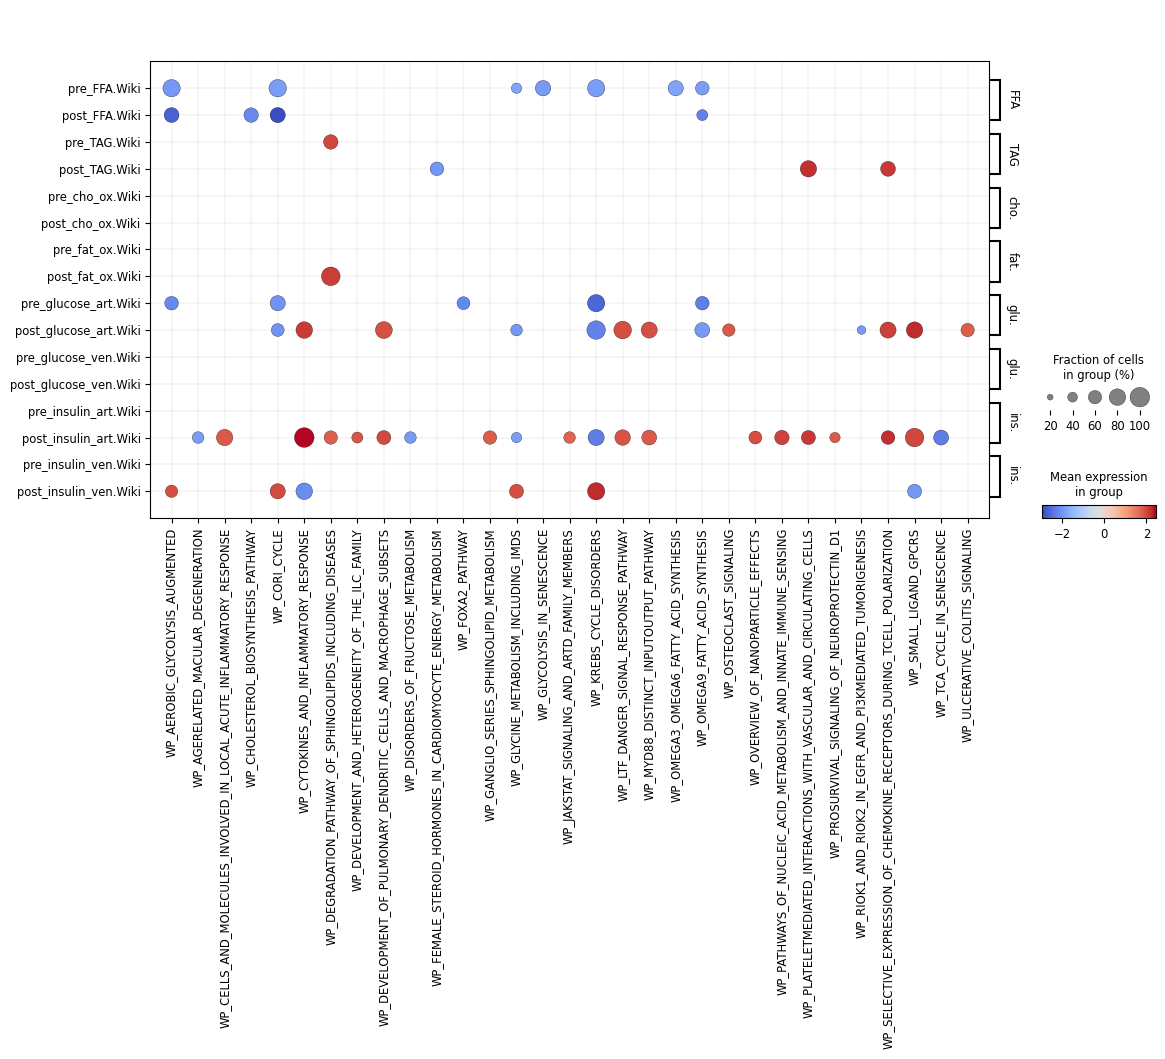

In [79]:
bs = 50
save_fig = False

assert (adata.obs_names == LE_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=LE_df.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True
    ) #, dendrogram=True)
    
    p.grid=True
    p.make_figure()
    
    if save_fig:
        plt.savefig(f'figures/Wiki_{i}.png', bbox_inches='tight')
        plt.close()

## Highlighted

In [176]:
gobp_names = pd.DataFrame(adatas["GOBP"].obs_names.to_series())
gobp_names.columns = ["name",]
gobp_names["name"] = gobp_names["name"].str.replace("GOBP_", "").str.lower().str.replace("_", " ").str.capitalize()
gobp_names.head()

,name
index,
GOBP_ACTIVATION_OF_IMMUNE_RESPONSE,Activation of immune response
GOBP_ACTIVATION_OF_INNATE_IMMUNE_RESPONSE,Activation of innate immune response
GOBP_ADAPTIVE_IMMUNE_RESPONSE,Adaptive immune response
GOBP_AEROBIC_RESPIRATION,Aerobic respiration
GOBP_ALPHA_AMINO_ACID_METABOLIC_PROCESS,Alpha amino acid metabolic process


In [177]:
adatas["GOBP"].obs.pathway = gobp_names.loc[adatas["GOBP"].obs.pathway, "name"]
LE_dfs["GOBP"]["pathway"] = gobp_names.loc[LE_dfs["GOBP"].index, "name"]

In [178]:
for db, adata in adatas.items():
    adata.var_names = adata.var_names.to_series().str.split(".", expand=True).iloc[:,0]
    LE_dfs[db].columns = LE_dfs[db].columns.to_series().str.split(".", expand=True).iloc[:,0]

In [179]:
adata_hl = ad.concat(adatas.values(), label="DB", keys=adatas.keys(), axis=0)

In [180]:
LE_df_hl = pd.concat(LE_dfs.values(), axis=0, )

In [181]:
adata = adata_hl
LE_df = LE_df_hl

In [276]:
markers_ = {colname: colname.split("_", maxsplit=1)[1].split(".")[0] for colname in adata.var_names}

markers = {}
for key, value in markers_.items():
    if value in markers:
        markers[value].append(key)
    else:
        markers[value] = [key,]

for key, value in markers.items():
    markers[key] = list(reversed(sorted(markers[key])))

In [183]:
adata.obs.index.name = "index"
vc = adata.obs.value_counts("pathway")

idx = adata.obs.pathway.isin(vc[vc > 1].index)

adata.obs["pathway_"] = adata.obs.pathway

adata.obs.loc[idx, "pathway_"] = adata.obs.loc[idx, "pathway"].astype("str") + ": " + adata.obs.loc[idx, "DB"].astype("str")

In [201]:
LE_df["pathway"] = adata.obs.loc[LE_df.index, "pathway_"]
LE_df.set_index("pathway", inplace=True)

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_8865/1569494721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LE_df["pathway"] = adata.obs.loc[LE_df.index, "pathway_"]


In [207]:
adata.obs_names = adata.obs.pathway_
adata.obs.index.name = "index"

In [189]:
LE_df = LE_df[adata.var_names]

In [226]:
LE_df.columns = LE_df.columns.astype(np.str_)

In [267]:
adata.obs["abs_max"] = np.nanmax(abs(adata.X), axis=1, )
adata = adata[adata.obs.sort_values("abs_max", ascending=False).index,:].copy()
adata.obs.pathway_ = pd.Categorical(adata.obs.pathway_, ordered=True, categories=adata.obs.pathway_)

In [268]:
LE_df = LE_df.loc[adata.obs_names,:].copy()

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/anndata/_core/anndata.py:1158: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


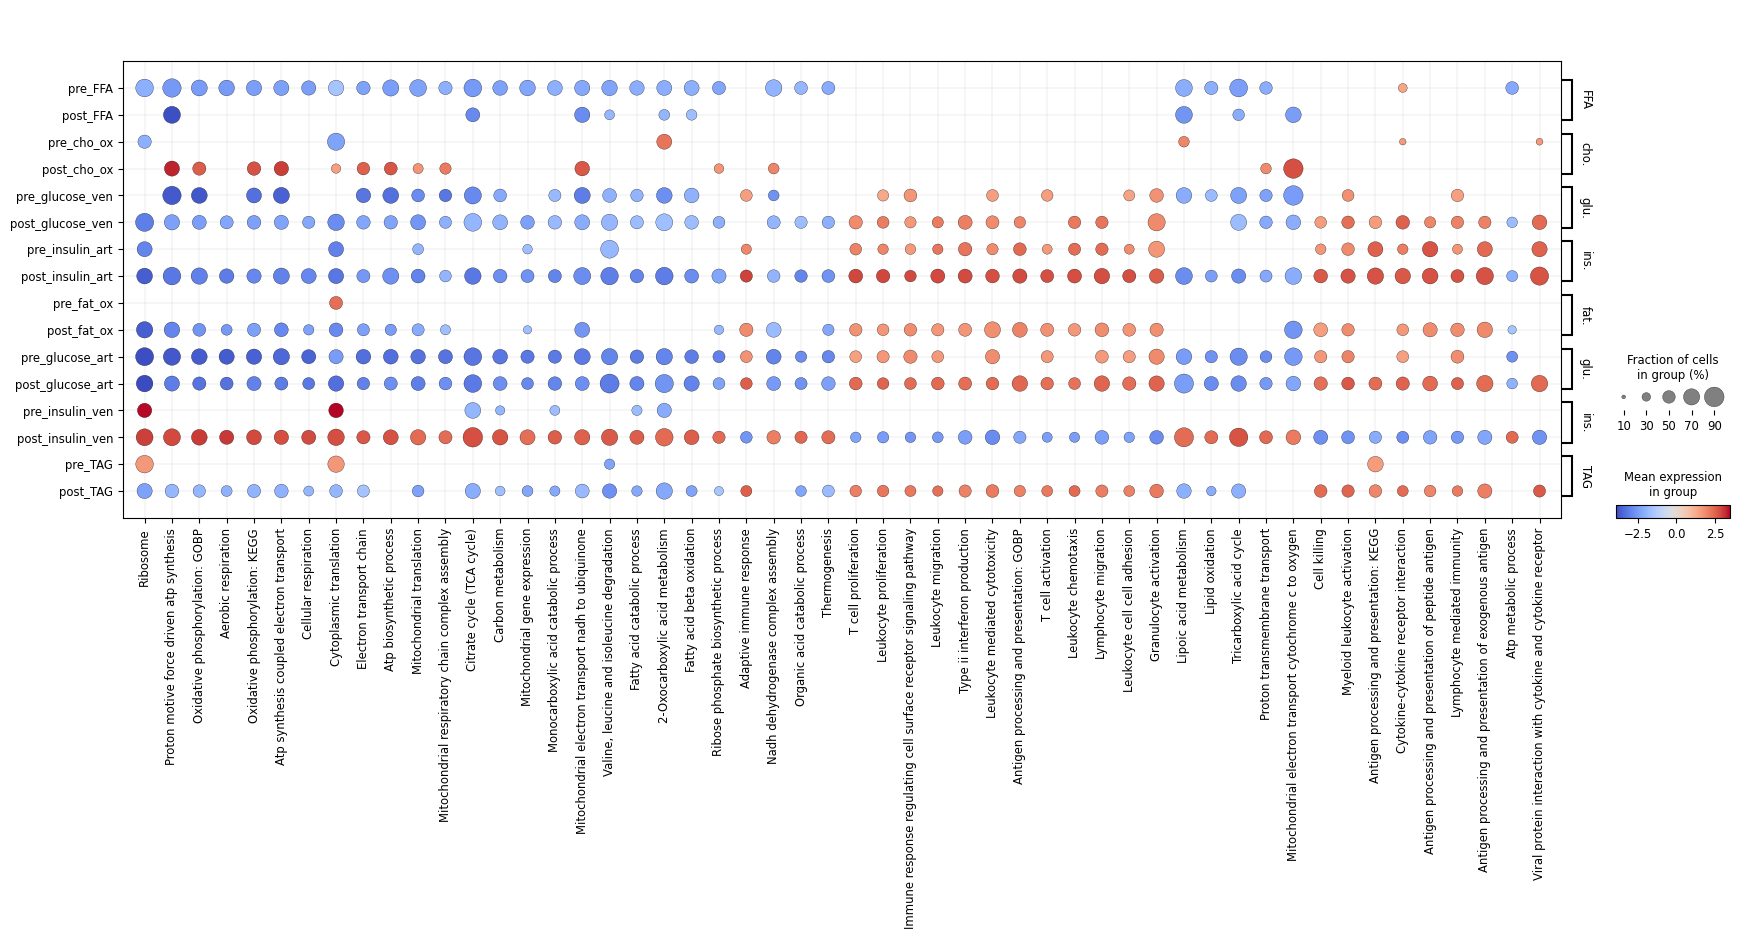

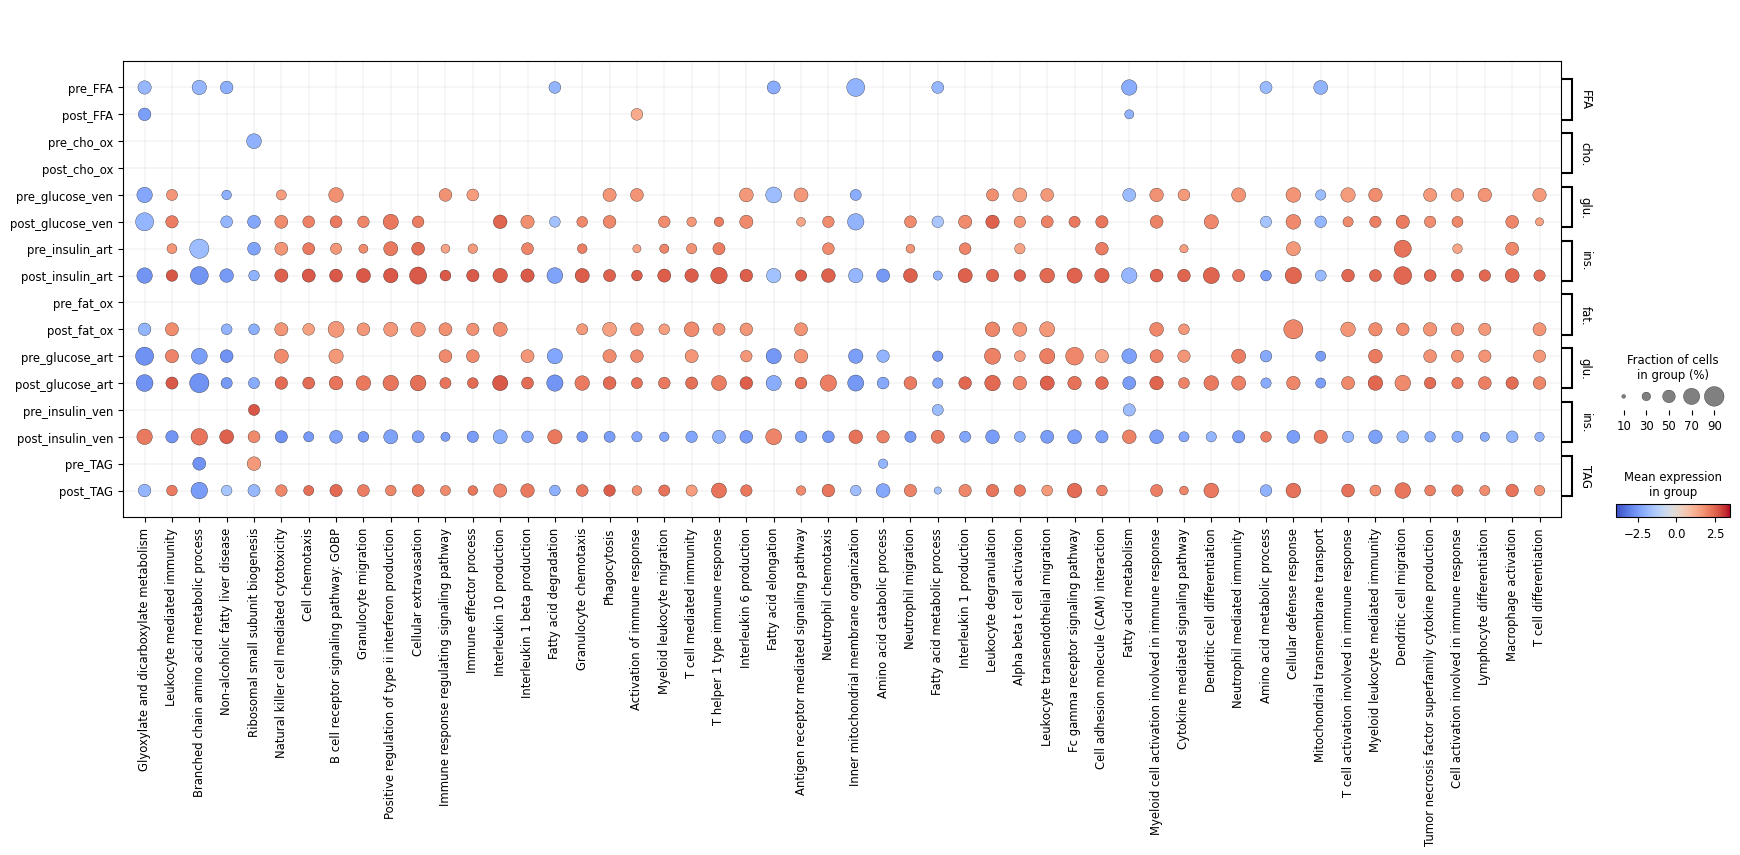

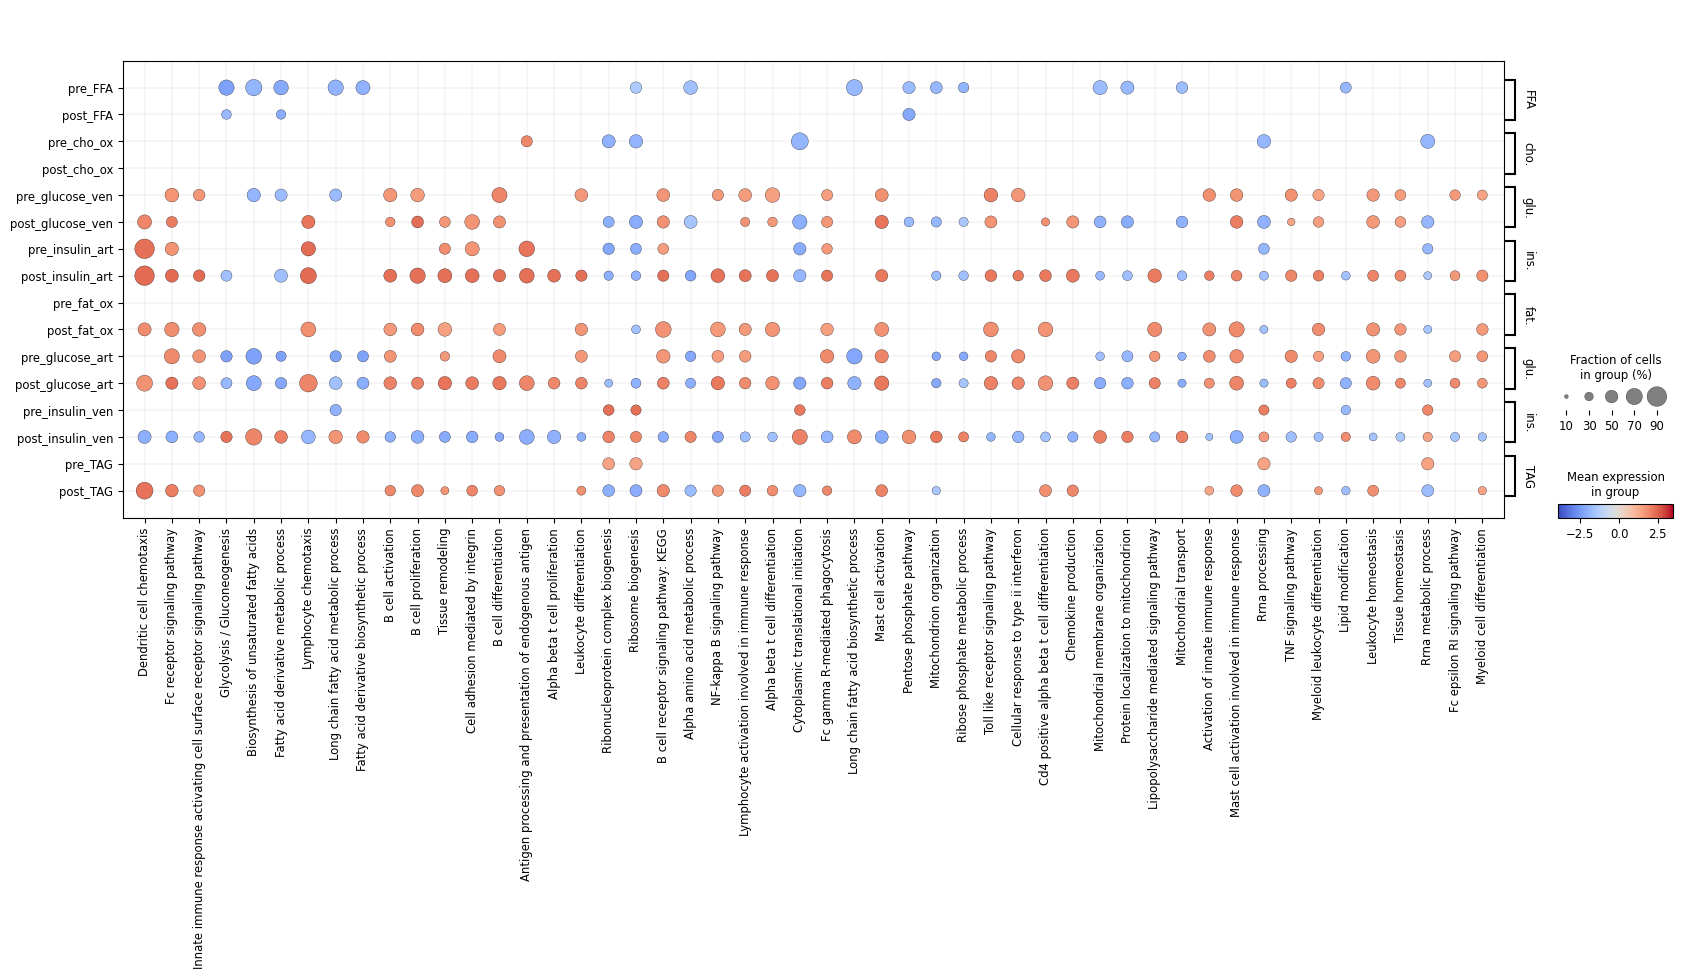

In [278]:
bs = 52
save_fig = False


assert (adata.obs_names == LE_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway_",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=LE_df.loc[adata[i:(i + bs),:].obs_names,:],
        swap_axes=True,
        return_fig=True
    ) #, dendrogram=True)
    
    p.grid=True
    p.group_cmaps = None
    p.make_figure()
    
    if save_fig:
        plt.savefig(f'figures/Wiki_{i}.png', bbox_inches='tight')
        plt.close()

# Dotplot function

In [19]:
from scanpy._utils import _doc_params, _empty

In [20]:
from scanpy.plotting._anndata import _prepare_dataframe
from scanpy.plotting._baseplot_class import _var_groups

In [21]:
from scanpy.plotting import DotPlot
from scanpy._utils import _doc_params, _empty
from scanpy.plotting._utils import (
    _dk,
    check_colornorm,
    fix_kwds,
    make_grid_spec,
    savefig_or_show,
)
from matplotlib import colormaps, gridspec
from scanpy.plotting._anndata import (
    VarGroups,
    _plot_dendrogram,
    _plot_var_groups_brackets,
    _prepare_dataframe,
    _reorder_categories_after_dendrogram,
)


class DotPlot_(DotPlot):

    
    DEFAULT_COLOR_LEGEND_TITLE = "NES"
    DEFAULT_SIZE_LEGEND_TITLE = "Leading Edge %"
    
    @staticmethod
    def _dotplot(  # noqa: PLR0912, PLR0913, PLR0915
        dot_size: pd.DataFrame,
        dot_color: pd.DataFrame,
        dot_ax,
        *,
        cmap,
        group_cmaps,
        color_on,
        dot_max: float | None,
        dot_min: float | None,
        standard_scale,
        smallest_dot: float,
        largest_dot: float,
        size_exponent: float,
        edge_color,
        edge_lw: float | None,
        grid: bool,
        x_padding: float,
        y_padding: float,
        vmin: float | None,
        vmax: float | None,
        vcenter: float | None,
        norm,
        are_axes_swapped: bool | None,
        **kwds,
    ):
        """Make a *dot plot* given two data frames.
    
        One containing the dot size and other containing the dot color.
        The indices and columns of the data frame are used to label the output image.
    
        The dots are plotted using :func:`matplotlib.pyplot.scatter`. Thus, additional
        arguments can be passed.
    
        Parameters
        ----------
        dot_size
            Data frame containing the dot_size.
        dot_color
            Data frame containing the dot_color, should have the same,
            shape, columns and indices as dot_size.
        dot_ax
            matplotlib axis
        cmap
        color_on
        dot_max
        dot_min
        standard_scale
        smallest_dot
        edge_color
        edge_lw
        grid
        x_padding
        y_padding
            See `style`
        kwds
            Are passed to :func:`matplotlib.pyplot.scatter`.
    
        Returns
        -------
        matplotlib.colors.Normalize, dot_min, dot_max
    
        """
        assert dot_size.shape == dot_color.shape, (
            f"please check that dot_size and dot_color dataframes have the same shape"
        )
        
        # assert list(dot_size.index) == list(dot_color.index), (
        #     f"please check that dot_size {list(dot_size.index)} and dot_color {list(dot_color.index)} dataframes have the same index"
        # )
        dot_size = dot_size.loc[dot_color.index, :]
    
        assert list(dot_size.columns) == list(dot_color.columns), (
            f"please check that the dot_size "
            f"and dot_color dataframes have the same columns"
        )
        match are_axes_swapped, standard_scale:
            case True, "group":
                group_axis = 1
            case True, "var":
                group_axis = 0
            case _, "group":
                group_axis = 0
            case _, "var":
                group_axis = 1
        if standard_scale is not None:
            dot_color = dot_color.sub(
                dot_color.min(axis=1 - group_axis), axis=group_axis
            )
            dot_color = dot_color.div(
                dot_color.max(axis=1 - group_axis), axis=group_axis
            ).fillna(0)
        # make scatter plot in which
        # x = var_names
        # y = groupby category
        # size = fraction
        # color = mean expression
    
        # +0.5 in y and x to set the dot center at 0.5 multiples
        # this facilitates dendrogram and totals alignment for
        # matrixplot, dotplot and stackec_violin using the same coordinates.
        y, x = np.indices(dot_color.shape)
        y = y.flatten() + 0.5
        x = x.flatten() + 0.5
        frac = dot_size.values.flatten()
        mean_flat = dot_color.values.flatten()
        cmap = colormaps.get_cmap(cmap)
        if dot_max is None:
            dot_max = np.ceil(max(frac) * 10) / 10
        elif dot_max < 0 or dot_max > 1:
            msg = "`dot_max` value has to be between 0 and 1"
            raise ValueError(msg)
        if dot_min is None:
            dot_min = 0
        elif dot_min < 0 or dot_min > 1:
            msg = "`dot_min` value has to be between 0 and 1"
            raise ValueError(msg)
    
        if dot_min != 0 or dot_max != 1:
            # clip frac between dot_min and  dot_max
            frac = np.clip(frac, dot_min, dot_max)
            old_range = dot_max - dot_min
            # re-scale frac between 0 and 1
            frac = (frac - dot_min) / old_range
    
        size = frac**size_exponent
        # rescale size to match smallest_dot and largest_dot
        size = size * (largest_dot - smallest_dot) + smallest_dot
        normalize = check_colornorm(vmin, vmax, vcenter, norm)
    
        if group_cmaps is not None:
            # Plotting logic for group-specific colormaps
            groups_iter = dot_color.columns if are_axes_swapped else dot_color.index
            n_vars = dot_color.shape[0] if are_axes_swapped else dot_color.shape[1]
            n_groups = len(groups_iter)
    
            # Here we loop through each group and plot it with its own cmap
            for group_idx, group_name in enumerate(groups_iter):
                group_cmap = group_cmaps[group_name]
                # Handle fallback case where group_cmap might be a string
                if isinstance(group_cmap, str):
                    group_cmap = colormaps.get_cmap(group_cmap)
    
                # Slice the flattened data arrays correctly depending on orientation
                if not are_axes_swapped:
                    # Slicing data for a whole row
                    indices = slice(group_idx * n_vars, (group_idx + 1) * n_vars)
                else:
                    # Slicing data for a whole column
                    indices = slice(group_idx, None, n_groups)
    
                x_group = x[indices]
                y_group = y[indices]
                size_group = size[indices]
                mean_group = mean_flat[indices]
    
                color = group_cmap(normalize(mean_group))
                kwds_scatter = fix_kwds(
                    kwds,
                    s=size_group,
                    color=color,
                    linewidth=edge_lw,
                    edgecolor=edge_color,
                )
                dot_ax.scatter(x_group, y_group, **kwds_scatter)
        elif color_on == "square":
            if edge_color is None:
                from seaborn.utils import relative_luminance
    
                # use either black or white for the edge color
                # depending on the luminance of the background
                # square color
                edge_color = []
                for color_value in cmap(normalize(mean_flat)):
                    lum = relative_luminance(color_value)
                    edge_color.append(".15" if lum > 0.408 else "w")
    
            edge_lw = 1.5 if edge_lw is None else edge_lw
    
            # first make a heatmap similar to `sc.pl.matrixplot`
            # (squares with the asigned colormap). Circles will be plotted
            # on top
            dot_ax.pcolor(dot_color.values, cmap=cmap, norm=normalize)
            for axis in ["top", "bottom", "left", "right"]:
                dot_ax.spines[axis].set_linewidth(1.5)
            # Create a temporary kwargs dict for this group's scatter call
            # to avoid modifying the original kwds dictionary within the loop.
            kwds_scatter = fix_kwds(
                kwds,
                s=size,
                linewidth=edge_lw,
                facecolor="none",
                edgecolor=edge_color,
            )
            dot_ax.scatter(x, y, **kwds_scatter)
        else:
            size = size.astype(np.float64)
            # print(y)
            # y += np.repeat(np.arange(int(y.shape[0]/2)), 2)
            # print(y)
            
            edge_color = "none" if edge_color is None else edge_color
            edge_lw = 0.0 if edge_lw is None else edge_lw
            color = cmap(normalize(mean_flat))
            kwds_scatter = fix_kwds(
                kwds,
                s=size,
                color=color,
                linewidth=edge_lw,
                edgecolor=edge_color,
            )
            dot_ax.scatter(x, y, **kwds_scatter)
    
        y_ticks = np.arange(dot_color.shape[0]) + 0.5
        dot_ax.set_yticks(y_ticks)
        dot_ax.set_yticklabels(
            [dot_color.index[idx] for idx, _ in enumerate(y_ticks)], minor=False
        )
    
        x_ticks = np.arange(dot_color.shape[1]) + 0.5
        dot_ax.set_xticks(x_ticks)
        dot_ax.set_xticklabels(
            [dot_color.columns[idx] for idx, _ in enumerate(x_ticks)],
            rotation=90,
            ha="center",
            minor=False,
        )
        dot_ax.tick_params(axis="both", labelsize="small")
        dot_ax.grid(visible=False)
    
        # to be consistent with the heatmap plot, is better to
        # invert the order of the y-axis, such that the first group is on
        # top
        dot_ax.set_ylim(dot_color.shape[0], 0)
        dot_ax.set_xlim(0, dot_color.shape[1])
    
        if color_on == "dot":
            # add padding to the x and y lims when the color is not in the square
            # default y range goes from 0.5 to num cols + 0.5
            # and default x range goes from 0.5 to num rows + 0.5, thus
            # the padding needs to be corrected.
            x_padding = x_padding - 0.5
            y_padding = y_padding - 0.5
            dot_ax.set_ylim(dot_color.shape[0] + y_padding, -y_padding)
    
            dot_ax.set_xlim(-x_padding, dot_color.shape[1] + x_padding)
    
        if grid:
            dot_ax.grid(visible=True, color="gray", linewidth=0.1)
            dot_ax.set_axisbelow(True)
    
        return normalize, dot_min, dot_max
    
    
    def _mainplot(self, ax):
        # work on a copy of the dataframes. This is to avoid changes
        # on the original data frames after repetitive calls to the
        # DotPlot object, for example once with swap_axes and other without
    
        _color_df = self.dot_color_df.copy()
        _size_df = self.dot_size_df.copy()
        if self.var_names_idx_order is not None:
            _color_df = _color_df.iloc[:, self.var_names_idx_order]
            _size_df = _size_df.iloc[:, self.var_names_idx_order]
    
        if self.categories_order is not None:
            _color_df = _color_df.loc[self.categories_order, :]
            _size_df = _size_df.loc[self.categories_order, :]
    
        if self.are_axes_swapped:
            _size_df = _size_df.T
            _color_df = _color_df.T
        self.cmap = self.kwds.pop("cmap", self.cmap)

        
        normalize, dot_min, dot_max = self._dotplot(
            _size_df,
            _color_df,
            ax,
            cmap=self.cmap,
            group_cmaps=self.group_cmaps,
            color_on=self.color_on,
            dot_max=self.dot_max,
            dot_min=self.dot_min,
            standard_scale=self.standard_scale,
            edge_color=self.dot_edge_color,
            edge_lw=self.dot_edge_lw,
            smallest_dot=self.smallest_dot,
            largest_dot=self.largest_dot,
            size_exponent=self.size_exponent,
            grid=self.grid,
            x_padding=self.plot_x_padding,
            y_padding=self.plot_y_padding,
            vmin=self.vboundnorm.vmin,
            vmax=self.vboundnorm.vmax,
            vcenter=self.vboundnorm.vcenter,
            norm=self.vboundnorm.norm,
            are_axes_swapped=self.are_axes_swapped,
            **self.kwds,
        )
    
        self.dot_min, self.dot_max = dot_min, dot_max
        return normalize
    
    def make_figure(self) -> None:  # noqa: PLR0912, PLR0915
        r"""Render the image but does not call :func:`matplotlib.pyplot.show`.
    
        Useful when several plots are put together into one figure.
    
        See Also
        --------
        `show()`: Renders and shows the plot.
        `savefig()`: Saves the plot.
    
        Examples
        --------
        >>> import scanpy as sc
        >>> import matplotlib.pyplot as plt
        >>> adata = sc.datasets.pbmc68k_reduced()
        >>> markers = ['C1QA', 'PSAP', 'CD79A', 'CD79B', 'CST3', 'LYZ']
        >>> fig, (ax0, ax1) = plt.subplots(1, 2)
        >>> sc.pl.MatrixPlot(adata, markers, groupby='bulk_labels', ax=ax0) \
        ...     .style(cmap='Blues', edge_color='none').make_figure()
        >>> sc.pl.DotPlot(adata, markers, groupby='bulk_labels', ax=ax1).make_figure()
    
        """
        category_height = self.DEFAULT_CATEGORY_HEIGHT
        category_width = self.DEFAULT_CATEGORY_WIDTH
    
        if self.height is None:
            mainplot_height = len(self.categories) * category_height
            mainplot_width = (
                len(self.var_names) * category_width + self.group_extra_size
            )
            if self.are_axes_swapped:
                mainplot_height, mainplot_width = mainplot_width, mainplot_height
    
            height = mainplot_height + 1  # +1 for labels
    
            # if the number of categories is small use
            # a larger height, otherwise the legends do not fit
            self.height = max([self.min_figure_height, height])
            self.width = mainplot_width + self.legends_width
        else:
            self.min_figure_height = self.height
            mainplot_height = self.height
    
            mainplot_width = self.width - (self.legends_width + self.group_extra_size)
    
        return_ax_dict = {}
        # define a layout of 1 rows x 2 columns
        #   first ax is for the main figure.
        #   second ax is to plot legends
        legends_width_spacer = 0.7 / self.width
    
        self.fig, gs = make_grid_spec(
            self.ax or (self.width, self.height),
            nrows=1,
            ncols=2,
            wspace=legends_width_spacer,
            width_ratios=[mainplot_width + self.group_extra_size, self.legends_width],
        )
    
        if self.var_groups:
            # add some space in case 'brackets' want to be plotted on top of the image
            if self.are_axes_swapped:
                var_groups_height = category_height
            else:
                var_groups_height = category_height / 2
    
        else:
            var_groups_height = 0
    
        mainplot_width = mainplot_width - self.group_extra_size
        spacer_height = self.height - var_groups_height - mainplot_height
        if not self.are_axes_swapped:
            height_ratios = [spacer_height, var_groups_height, mainplot_height]
            width_ratios = [mainplot_width, self.group_extra_size]
    
        else:
            height_ratios = [spacer_height, self.group_extra_size, mainplot_height]
            width_ratios = [mainplot_width, var_groups_height]
            # gridspec is the same but rows and columns are swapped
    
        if self.fig_title is not None and self.fig_title.strip() != "":
            # for the figure title use the ax that contains
            # all the main graphical elements (main plot, dendrogram etc)
            # otherwise the title may overlay with the figure.
            # also, this puts the title centered on the main figure and not
            # centered between the main figure and the legends
            _ax = self.fig.add_subplot(gs[0, 0])
            _ax.axis("off")
            _ax.set_title(self.fig_title)
    
        # the main plot is divided into three rows and two columns
        # first row is an spacer that is adjusted in case the
        #           legends need more height than the main plot
        # second row is for brackets (if needed),
        # third row is for mainplot and dendrogram/totals (legend goes in gs[0,1]
        # defined earlier)
        mainplot_gs = gridspec.GridSpecFromSubplotSpec(
            nrows=3,
            ncols=2,
            wspace=self.wspace,
            hspace=0.0,
            subplot_spec=gs[0, 0],
            width_ratios=width_ratios,
            height_ratios=height_ratios,
        )
        main_ax = self.fig.add_subplot(mainplot_gs[2, 0])
        return_ax_dict["mainplot_ax"] = main_ax
        if not self.are_axes_swapped:
            if self.plot_group_extra is not None:
                group_extra_ax = self.fig.add_subplot(mainplot_gs[2, 1], sharey=main_ax)
                group_extra_orientation = "right"
            if self.var_groups:
                gene_groups_ax = self.fig.add_subplot(mainplot_gs[1, 0], sharex=main_ax)
                var_group_orientation = "top"
        else:
            if self.plot_group_extra:
                group_extra_ax = self.fig.add_subplot(mainplot_gs[1, 0], sharex=main_ax)
                group_extra_orientation = "top"
            if self.var_groups:
                gene_groups_ax = self.fig.add_subplot(mainplot_gs[2, 1], sharey=main_ax)
                var_group_orientation = "right"
    S
        if self.plot_group_extra is not None:
            if self.plot_group_extra["kind"] == "dendrogram":
                _plot_dendrogram(
                    group_extra_ax,
                    self.adata,
                    self.groupby,
                    dendrogram_key=self.plot_group_extra["dendrogram_key"],
                    ticks=self.plot_group_extra["dendrogram_ticks"],
                    orientation=group_extra_orientation,
                )
            if self.plot_group_extra["kind"] == "group_totals":
                self._plot_totals(group_extra_ax, group_extra_orientation)
    
            return_ax_dict["group_extra_ax"] = group_extra_ax
    
        # plot group legends on top or left of main_ax (if given)
        if self.var_groups:
            _plot_var_groups_brackets(
                gene_groups_ax,
                var_groups=self.var_groups,
                rotation=self.var_group_rotation,
                left_adjustment=0.2,
                right_adjustment=0.7,
                orientation=var_group_orientation,
                wide=True,
            )
            return_ax_dict["gene_group_ax"] = gene_groups_ax
    
        # plot the mainplot
        normalize = self._mainplot(main_ax)
    
        # code from pandas.plot in add_totals adds
        # minor ticks that need to be removed
        main_ax.yaxis.set_tick_params(which="minor", left=False, right=False)
        main_ax.xaxis.set_tick_params(which="minor", top=False, bottom=False, length=0)
        main_ax.set_zorder(100)
        if self.legends_width > 0:
            legend_ax = self.fig.add_subplot(gs[0, 1])
            self._plot_legend(legend_ax, return_ax_dict, normalize)
    
        self.ax_dict = return_ax_dict


def dotplot(  # noqa: PLR0913
    adata,
    var_names,
    groupby,
    *,
    use_raw: bool | None = None,
    log: bool = False,
    num_categories: int = 7,
    categories_order = None,
    expression_cutoff: float = 0.0,
    mean_only_expressed: bool = False,
    standard_scale = None,
    title: str | None = None,
    colorbar_title: str | None = DotPlot_.DEFAULT_COLOR_LEGEND_TITLE,
    size_title: str | None = DotPlot_.DEFAULT_SIZE_LEGEND_TITLE,
    figsize: tuple[float, float] | None = None,
    dendrogram: bool | str = False,
    gene_symbols: str | None = None,
    var_group_positions = None,
    var_group_labels = None,
    var_group_rotation: float | None = None,
    layer: str | None = None,
    swap_axes: bool | None = False,
    dot_color_df: pd.DataFrame | None = None,
    show: bool | None = None,
    save: str | bool | None = None,
    ax = None,
    return_fig: bool | None = False,
    vmin: float | None = None,
    vmax: float | None = None,
    vcenter: float | None = None,
    norm = None,
    # Style parameters
    cmap = DotPlot_.DEFAULT_COLORMAP,
    dot_max: float | None = DotPlot_.DEFAULT_DOT_MAX,
    dot_min: float | None = DotPlot_.DEFAULT_DOT_MIN,
    smallest_dot: float = DotPlot_.DEFAULT_SMALLEST_DOT,
    **kwds,
) -> DotPlot_ | dict | None:
    r"""Make a *dot plot* of the expression values of `var_names`.

    For each var_name and each `groupby` category a dot is plotted.
    Each dot represents two values: mean expression within each category
    (visualized by color) and fraction of cells expressing the `var_name` in the
    category (visualized by the size of the dot). If `groupby` is not given,
    the dotplot assumes that all data belongs to a single category.

    .. note::
       A gene is considered expressed if the expression value in the `adata` (or
       `adata.raw`) is above the specified threshold which is zero by default.

    An example of dotplot usage is to visualize, for multiple marker genes,
    the mean value and the percentage of cells expressing the gene
    across  multiple clusters.

    This function provides a convenient interface to the :class:`~scanpy.pl.DotPlot`
    class. If you need more flexibility, you should use :class:`~scanpy.pl.DotPlot`
    directly.

    Parameters
    ----------
    {common_plot_args}
    {groupby_plots_args}
    size_title
        Title for the size legend. New line character (\n) can be used.
    expression_cutoff
        Expression cutoff that is used for binarizing the gene expression and
        determining the fraction of cells expressing given genes. A gene is
        expressed only if the expression value is greater than this threshold.
    mean_only_expressed
        If True, gene expression is averaged only over the cells
        expressing the given genes.
    dot_max
        If ``None``, the maximum dot size is set to the maximum fraction value found
        (e.g. 0.6). If given, the value should be a number between 0 and 1.
        All fractions larger than dot_max are clipped to this value.
    dot_min
        If ``None``, the minimum dot size is set to 0. If given,
        the value should be a number between 0 and 1.
        All fractions smaller than dot_min are clipped to this value.
    smallest_dot
        All expression levels with `dot_min` are plotted with this size.
    {show_save_ax}
    {vminmax}
    kwds
        Are passed to :func:`matplotlib.pyplot.scatter`.

    Returns
    -------
    If `return_fig` is `True`, returns a :class:`~scanpy.pl.DotPlot` object,
    else if `show` is false, return axes dict

    See Also
    --------
    :class:`~scanpy.pl.DotPlot`: The DotPlot class can be used to to control
        several visual parameters not available in this function.
    :func:`~scanpy.pl.rank_genes_groups_dotplot`: to plot marker genes
        identified using the :func:`~scanpy.tl.rank_genes_groups` function.

    Examples
    --------
    Create a dot plot using the given markers and the PBMC example dataset grouped by
    the category 'bulk_labels'.

    .. plot::
        :context: close-figs

        import scanpy as sc
        adata = sc.datasets.pbmc68k_reduced()
        markers = ['C1QA', 'PSAP', 'CD79A', 'CD79B', 'CST3', 'LYZ']
        sc.pl.dotplot(adata, markers, groupby='bulk_labels', dendrogram=True)

    Using var_names as dict:

    .. plot::
        :context: close-figs

        markers = {{'T-cell': 'CD3D', 'B-cell': 'CD79A', 'myeloid': 'CST3'}}
        sc.pl.dotplot(adata, markers, groupby='bulk_labels', dendrogram=True)

    Get DotPlot object for fine tuning

    .. plot::
        :context: close-figs

        dp = sc.pl.dotplot(adata, markers, 'bulk_labels', return_fig=True)
        dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).show()

    The axes used can be obtained using the get_axes() method

    .. code-block:: python

        axes_dict = dp.get_axes()
        print(axes_dict)

    """
    # backwards compatibility: previous version of dotplot used `color_map`
    # instead of `cmap`
    cmap = kwds.pop("color_map", cmap)

    dp = DotPlot_(
        adata,
        var_names,
        groupby,
        use_raw=use_raw,
        log=log,
        num_categories=num_categories,
        categories_order=categories_order,
        expression_cutoff=expression_cutoff,
        mean_only_expressed=mean_only_expressed,
        standard_scale=standard_scale,
        title=title,
        figsize=figsize,
        gene_symbols=gene_symbols,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        var_group_rotation=var_group_rotation,
        layer=layer,
        dot_color_df=dot_color_df,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        vcenter=vcenter,
        norm=norm,
        **kwds,
    )

    if dendrogram:
        dp.add_dendrogram(dendrogram_key=_dk(dendrogram))
    if swap_axes:
        dp.swap_axes()

    dp = dp.style(
        cmap=cmap,
        dot_max=dot_max,
        dot_min=dot_min,
        smallest_dot=smallest_dot,
        dot_edge_lw=kwds.pop("linewidth", _empty),
    ).legend(colorbar_title=colorbar_title, size_title=size_title)

    if return_fig:
        return dp
    else:
        dp.make_figure()
        savefig_or_show(DotPlot.DEFAULT_SAVE_PREFIX, show=show, save=save)
        # show = settings.autoshow if show is None else show
        # if not show:
            # return dp.get_axes()

# PPP check

In [49]:
kegg_pr_df

,post_FFA.KEGG,post_TAG.KEGG,post_cho_ox.KEGG,post_fat_ox.KEGG,post_glucose_art.KEGG,post_glucose_ven.KEGG,post_insulin_art.KEGG,post_insulin_ven.KEGG,pre_FFA.KEGG,pre_TAG.KEGG,pre_cho_ox.KEGG,pre_fat_ox.KEGG,pre_glucose_art.KEGG,pre_glucose_ven.KEGG,pre_insulin_art.KEGG,pre_insulin_ven.KEGG
pval,0.000251,0.59115,0.970012,0.65,0.037512,0.002489,0.070576,0.002648,0.001005,0.536325,0.24435,0.690323,0.034384,0.552795,0.381494,0.371859
padj,0.00882,0.76476,0.993118,0.754698,0.070342,0.01352,0.119808,0.009034,0.008062,0.847161,0.625249,1.0,0.078721,0.750596,0.686329,0.650251
log2err,0.498493,0.064503,0.0199,0.111918,0.321776,0.431708,0.287805,0.431708,0.45506,0.045497,0.099928,0.042588,0.321776,0.146416,0.082434,0.085536
ES,-0.491127,-0.269722,-0.190205,-0.22795,-0.414044,-0.565985,-0.374305,0.554123,-0.602489,0.3311,-0.379193,-0.28642,-0.39131,-0.233176,-0.313414,-0.32306
NES,-2.231215,-0.910799,-0.580675,-0.893216,-1.515827,-1.781414,-1.430225,1.808604,-1.794459,0.982126,-1.185769,-0.856966,-1.474281,-0.938722,-1.042326,-1.055289
size,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,25
leadingEdge,2539|230|5634|6888|226|132158|25796|23729|2821...,5236|5631|2821|23729|7086|51071|132158,6120|5213|5631|5634|55276|9563|5226|5214,132158|23729|9104|5211|22934|226,6888|23729|226|7086|2821|132158|2539|25796|521...,5211|23729|51071|226|2821|64080|25796|132158|7086,2821|132158|5236|23729|6120|2539|226|5213|5634...,5236|6888|2821|2539|6120|226|25796|230|132158|...,5236|230|6888|9104|25796|2539|226|5211|6120|52...,414328|5213|5226|230|64080|226|51071|5211|5631...,5226|51071|2539|414328|230|23729|9563|22934|68...,5211|9104|5236|5631,7086|6888|25796|2539|5631|2821|9104|230|226|5226,5631|25796|7086|64080|5211|2821,51071|2539|5634|2821|22934|132158|6888|23729|5...,5213|5211|230|5631|7086|64080


In [50]:
reactome_pr_df

,post_FFA.reactome,post_TAG.reactome,post_cho_ox.reactome,post_fat_ox.reactome,post_glucose_art.reactome,post_glucose_ven.reactome,post_insulin_art.reactome,post_insulin_ven.reactome,pre_FFA.reactome,pre_TAG.reactome,pre_cho_ox.reactome,pre_fat_ox.reactome,pre_glucose_art.reactome,pre_glucose_ven.reactome,pre_insulin_art.reactome,pre_insulin_ven.reactome
pval,0.024506,0.576427,0.84204,0.876902,0.096535,0.038842,0.554124,0.037119,0.031477,0.601636,0.049927,0.762987,0.044422,0.230769,0.210054,0.32381
padj,0.24094,0.920081,0.953543,0.965552,0.25053,0.140548,0.748994,0.140939,0.138932,0.778464,0.185127,1.0,0.18013,0.449298,0.472332,0.636435
log2err,0.352488,0.067676,0.031565,0.034716,0.227987,0.321776,0.08731,0.321776,0.321776,0.044329,0.245042,0.082434,0.321776,0.197822,0.12564,0.11524
ES,-0.475261,-0.320349,-0.271056,0.247456,-0.468565,-0.588408,-0.300668,0.558825,-0.601995,0.360647,-0.539708,0.267169,-0.511036,-0.360495,-0.442297,0.386065
NES,-1.675315,-0.91687,-0.712982,0.6659,-1.381109,-1.574149,-0.936243,1.575893,-1.558182,0.936047,-1.436687,0.772588,-1.560113,-1.190102,-1.230696,1.108525
size,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13
leadingEdge,2539|5634|6888|25796|23729,5631|23729|7086|51071,6120|5631|5634|55276|5226,5631|51071|6120|5634,6888|23729|7086|2539|25796,23729|51071|64080|25796|7086|2539|6888|55276|5226,23729|6120|2539|5634|7086|6888,6888|2539|6120|25796|5634|5226|7086|22934,6888|25796|2539|6120|5226|5631,5226|64080|51071|5631|22934|6888|25796|6120|25...,5226|51071|2539|23729|22934|6888|55276,23729|51071|2539,7086|6888|25796|2539|5631,5631|25796|7086|64080,51071|2539|5634|22934|6888|23729|55276,51071|55276


In [51]:
gobp_pr_df

,post_FFA.GOBP,post_TAG.GOBP,post_cho_ox.GOBP,post_fat_ox.GOBP,post_glucose_art.GOBP,post_glucose_ven.GOBP,post_insulin_art.GOBP,post_insulin_ven.GOBP,pre_FFA.GOBP,pre_TAG.GOBP,pre_cho_ox.GOBP,pre_fat_ox.GOBP,pre_glucose_art.GOBP,pre_glucose_ven.GOBP,pre_insulin_art.GOBP,pre_insulin_ven.GOBP
pval,0.001078,0.553704,0.95267,0.843112,0.001553,0.004657,0.024074,0.023788,0.009152,0.903825,0.048316,0.341379,0.029371,0.608466,0.171378,0.979638
padj,0.074562,0.832157,0.984455,0.932661,0.010811,0.053897,0.08464,0.115044,0.160173,1.0,0.303094,1.0,0.13449,0.797147,0.476796,1.0
log2err,0.45506,0.069946,0.023933,0.032724,0.45506,0.407018,0.352488,0.352488,0.38073,0.020928,0.248911,0.138022,0.352488,0.126876,0.1396,0.052269
ES,-0.523564,-0.304756,-0.213948,0.243181,-0.595856,-0.610973,-0.46909,0.550426,-0.593669,0.23093,-0.49732,0.327872,-0.467052,-0.237236,-0.420309,0.175137
NES,-2.074658,-0.943629,-0.606263,0.720191,-1.98109,-1.791846,-1.57398,1.651361,-1.670412,0.647926,-1.462659,1.083748,-1.609691,-0.895911,-1.271414,0.555294
size,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
leadingEdge,2539|64223|5634|6888|25796|23729,32|23729|7086|51071|57521|57103|6120|2475,2475|6120|5634|57103|9563|5226,2475|51071|57103|6120|5634,64223|6888|23729|57521|7086|2539|25796|32|51071,23729|51071|64223|7157|64080|25796|57521|7086|...,64223|32|57521|23729|6120|2539|5634|7086|6888,6888|2539|64223|6120|25796|9563|5634|5226|7086...,6888|25796|2539|6120|64223|5226,5226|7157|64080|51071|22934|6888|25796|6120|95...,5226|2475|51071|2539|23729|9563|22934|6888,2475|23729|51071|2539,7086|6888|25796|64223|2539,64223|25796|7086|64080,51071|2539|5634|22934|7157|6888|32|23729,51071


# preTAG check

In [85]:
import seaborn as sns

In [81]:
cors = pd.read_csv("../outputs/cors/pre_TAG.csv")
cors

,gene,pheno,r,pvalue,median_expr
0,ENSG00000000003.16,TAG (mmol/L),0.228163,0.333285,23.060
1,ENSG00000000005.6,TAG (mmol/L),0.548193,0.012332,36.655
2,ENSG00000000419.14,TAG (mmol/L),-0.000753,0.997486,41.735
3,ENSG00000000457.14,TAG (mmol/L),-0.225612,0.338865,5.420
4,ENSG00000000460.17,TAG (mmol/L),0.147646,0.534470,1.850
...,...,...,...,...,...
17813,ENSG00000310536.1,TAG (mmol/L),0.196234,0.407000,0.865
17814,ENSG00000310537.1,TAG (mmol/L),0.065512,0.783770,1.195
17815,ENSG00000310539.1,TAG (mmol/L),0.021116,0.929588,0.415
17816,ENSG00000310560.1,TAG (mmol/L),0.567985,0.008987,15.060


In [82]:
cors["gene_id"] = cors.gene.str.split(".", expand=True).iloc[:,0]

In [83]:
cors.sort_values("r", ascending=False)

,gene,pheno,r,pvalue,median_expr,gene_id
7931,ENSG00000159685.11,TAG (mmol/L),0.879473,3.265616e-07,6.785,ENSG00000159685
6145,ENSG00000139910.20,TAG (mmol/L),0.866291,7.905212e-07,31.815,ENSG00000139910
15502,ENSG00000269973.1,TAG (mmol/L),0.860264,1.148777e-06,1.080,ENSG00000269973
16504,ENSG00000286153.2,TAG (mmol/L),0.858274,1.294837e-06,0.770,ENSG00000286153
9155,ENSG00000167645.17,TAG (mmol/L),0.850905,1.986459e-06,21.535,ENSG00000167645
...,...,...,...,...,...,...
17446,ENSG00000298117.1,TAG (mmol/L),-0.728916,2.666530e-04,0.435,ENSG00000298117
2676,ENSG00000106617.16,TAG (mmol/L),-0.818525,1.027795e-05,23.625,ENSG00000106617
14001,ENSG00000240409.1,TAG (mmol/L),NaN,NaN,0.000,ENSG00000240409
15896,ENSG00000273658.1,TAG (mmol/L),NaN,NaN,0.000,ENSG00000273658


<Axes: xlabel='r', ylabel='Count'>

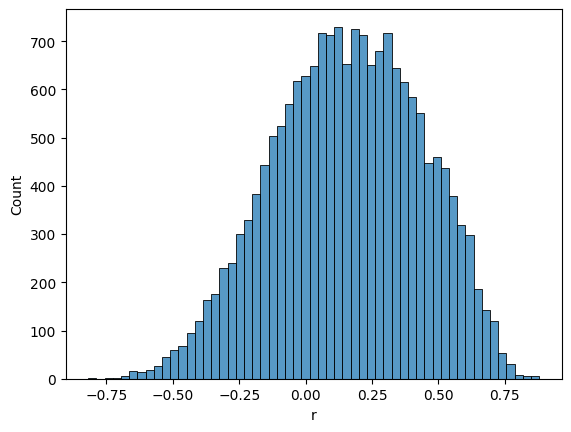

In [86]:
sns.histplot(cors.r)